# **Projet Machine Learning RH**
## Analyse de l’attrition, segmentation et recommandation des employés

#  Tableau récapitulatif du projet

Ce tableau présente la répartition des Data Science Objectives (DSO), des modèles utilisés, ainsi que la contribution de chaque membre de l’équipe.

---

| BO | DSO | Modèles utilisés | Étudiants |
|----|-----|----------------|-----------|
| **DSO1** | Prédiction de l’attrition des employés | - Random Forest<br>- Random Forest optimisé<br>- Random Forest + SMOTE<br>- XGBoost<br>- XGBoost optimisé<br>- **SHAP (interprétation)**<br><br>🔧 Techniques : SMOTE, tuning, seuil, class_weight | 👤 **Ons Kochtane** → Random Forest + amélioration + SHAP<br>👤 **Sahar Ouji Boughanmi** → XGBoost + tuning |
| **DSO2** | Segmentation des employés | - K-Means<br>- DBSCAN<br>- PCA<br><br>🔧 Techniques : normalisation, choix du nombre de clusters, tuning eps | 👤 **Marwa Labidi** → K-Means + PCA<br>👤 **Ghada Mahmoud** → DBSCAN + tuning eps |
| **DSO3** | Recommandation intelligente | - Régression linéaire<br>- Régression polynomiale<br><br>🔧 Techniques : normalisation, feature engineering | 👤 **Amin** → Régression + benchmarking |

---

##  Objectif global

- DSO1 : prédire les employés à risque d’attrition  
- DSO2 : segmenter les employés en groupes homogènes  
- DSO3 : recommander les employés les plus adaptés aux activités  

---

## Approche utilisée

- Machine Learning supervisé (DSO1, DSO3)
- Machine Learning non supervisé (DSO2)
- Optimisation des modèles (tuning, SMOTE, seuil)
- Interprétation des résultats (SHAP)

---

# **Etape 1: Data Understanding : analyse exploratoire des données (plots, graphiques, visualisations pertinentes, etc.)**

In [5]:
import pandas as pd
from sklearn.cluster import KMeans

In [6]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition (1).csv to WA_Fn-UseC_-HR-Employee-Attrition (1) (1).csv


In [7]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
df.shape

(1470, 35)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


**Attrition Globale (Important pour DSO1 – Prédiction)**

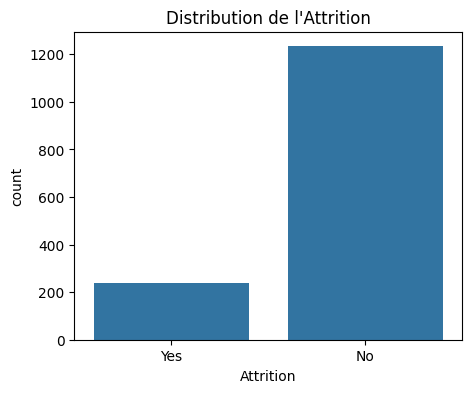

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title("Distribution de l'Attrition")
plt.show()

Comprendre l’équilibre des classes avant de faire de la classification.

--> La majorité des employés restent dans l’entreprise, tandis qu’une minorité quitte l’organisation.
Le dataset est déséquilibré, ce qui devra être pris en compte lors de l’entraînement du modèle prédictif.


**Attrition vs Ancienneté (Facteur clé DSO1 & DSO2 ) -- BoxPlot**

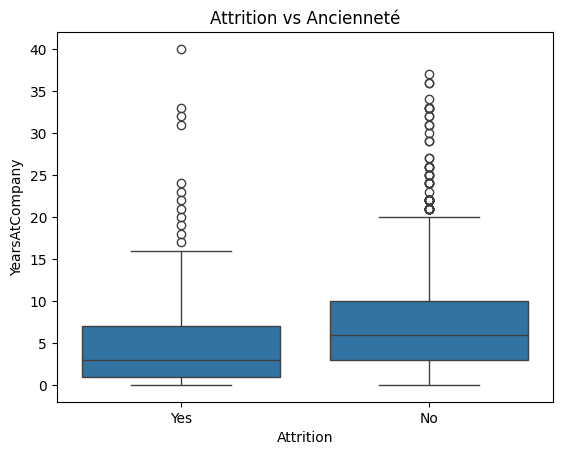

In [15]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Attrition vs Ancienneté")
plt.show()

Identifier si les départs concernent les nouveaux ou anciens employés.

--> Les employés quittant l’entreprise ont généralement une ancienneté plus faible.
Le risque d’attrition est donc plus élevé durant les premières années.

**Box Plot — Salaire vs Attrition**

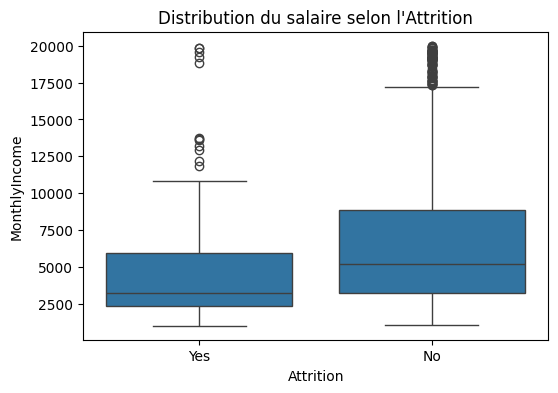

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Distribution du salaire selon l'Attrition")
plt.show()

Comparer les salaires des employés qui quittent l’entreprise et ceux qui restent afin d’évaluer si la rémunération influence l’attrition.

--> Le box plot montre que les employés ayant quitté l’entreprise présentent généralement des salaires plus faibles que ceux qui restent.
Cela suggère que la rémunération peut être un facteur influençant la décision de départ, et doit être prise en compte dans les actions de rétention et dans le modèle prédictif.

**Attrition vs JobLevel (Important pour recommandation DSO3)**

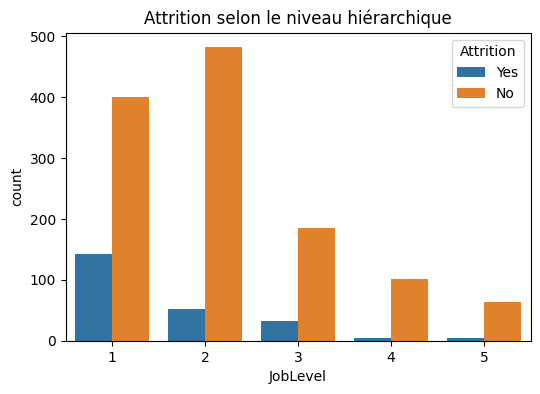

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='JobLevel', hue='Attrition', data=df)
plt.title("Attrition selon le niveau hiérarchique")
plt.show()

Mesurer l’impact du niveau professionnel sur la rétention.

--> Les niveaux hiérarchiques bas présentent davantage de départs, indiquant un manque de progression ou d’engagement initial.

**Performance vs Expérience (Clé pour DSO2 – Segmentation)**

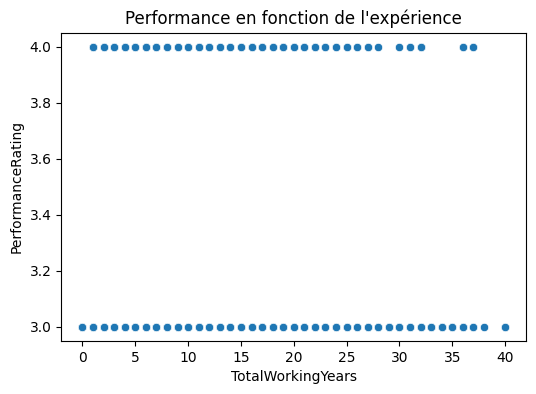

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TotalWorkingYears', y='PerformanceRating', data=df)
plt.title("Performance en fonction de l'expérience")
plt.show()

Identifier des profils types pour le clustering.

--> La performance reste relativement stable quel que soit le nombre d’années d’expérience, ce qui montre que l’expérience seule n’explique pas la performance.

**Impact des Heures Supplémentaires (Facteur RH critique)**

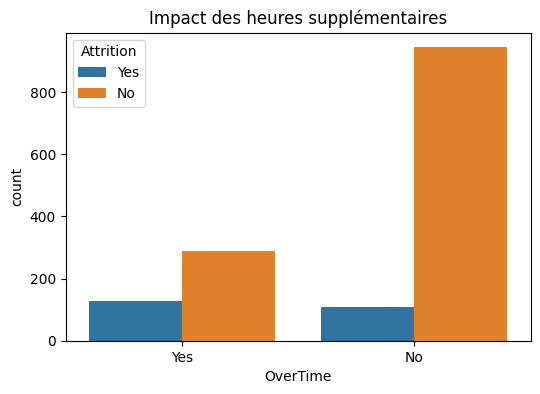

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Impact des heures supplémentaires")
plt.show()

Analyser la surcharge de travail → facteur décisionnel RH.

--> Les employés effectuant des heures supplémentaires quittent plus fréquemment l’entreprise, suggérant un lien entre surcharge de travail et attrition.

**Distribution du Revenu (Utile pour recommandation DSO3)**

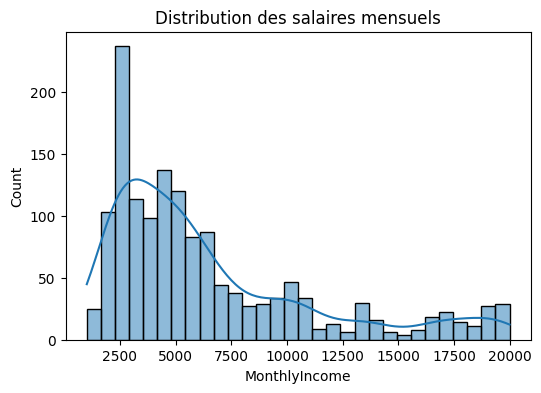

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
plt.title("Distribution des salaires mensuels")
plt.show()

Comprendre la structure salariale pour recommander des profils adaptés.

--> La distribution des salaires est hétérogène, reflétant la diversité des postes et niveaux d’expérience.

**Répartition des employés par Département (Contexte organisationnel)**

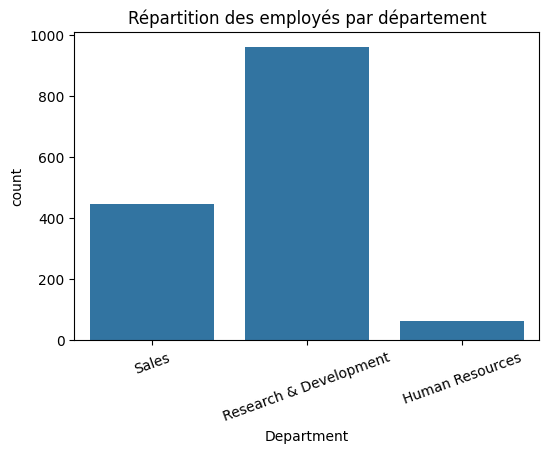

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Department', data=df)
plt.title("Répartition des employés par département")
plt.xticks(rotation=20)
plt.show()

Comprendre où se situent les ressources humaines.

--> La majorité des employés appartient au département R&D, ce qui influencera les recommandations et l’analyse des risques.

**Matrice de Corrélation**

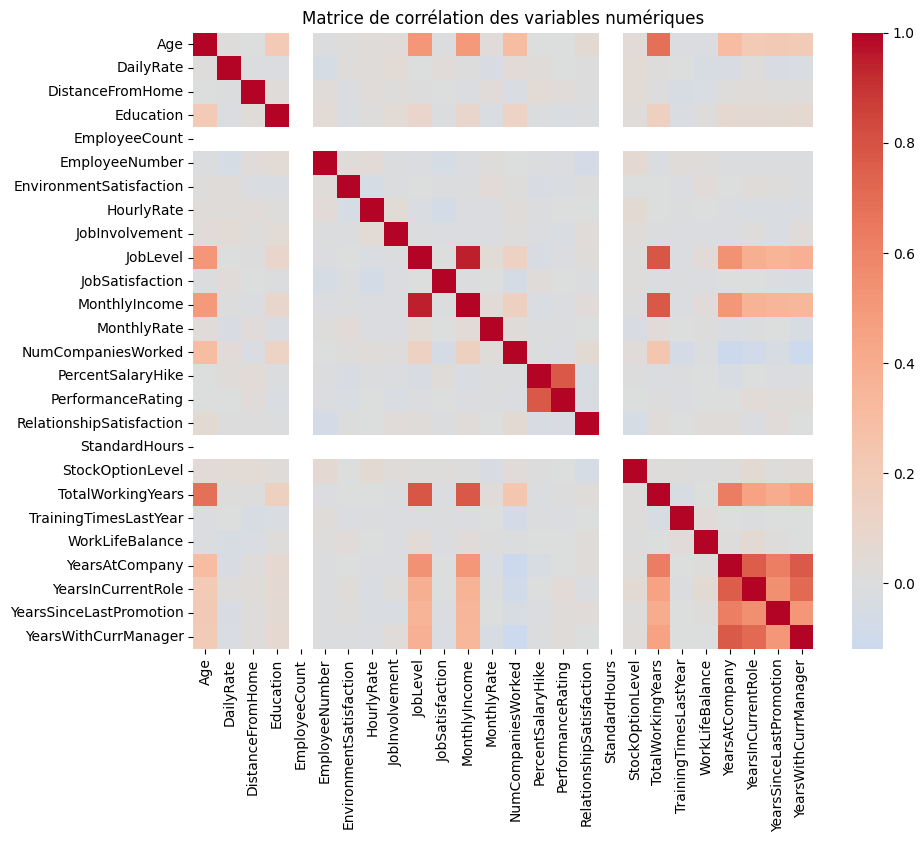

In [22]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

Identifier les variables redondantes → nécessaire pour PCA et modèles.

--> Certaines variables liées à l’expérience et à l’ancienneté sont fortement corrélées, justifiant l’utilisation d’une réduction de dimension (PCA).

# **Data Preparation : description détaillée de toutes les étapes de nettoyage et de préparation des données ,avec une application obligatoire de l’ACP, interprétée et accompagnée d’insights pertinents.**

**ÉTAPE 1 : vérification & suppression des doublons**

In [23]:
# Compter les doublons
print("Nombre de doublons :", df.duplicated().sum())

# Supprimer les doublons éventuels
df = df.drop_duplicates()

Nombre de doublons : 0


 Cette vérification garantit que chaque employé est représenté une seule fois dans le dataset.

**ÉTAPE 2 : Vérifier les valeurs manquantes**

In [24]:
# Compter les valeurs manquantes par colonne
print(df.isnull().sum())

# Optionnel : supprimer ou imputer les valeurs manquantes
df = df.dropna()  # si on veut supprimer les lignes avec valeurs manquantes

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

--> S’assurer que toutes les variables sont complètes afin que les modèles ML puissent s’entraîner sans erreurs.

**ÉTAPE 3 : Suppression des colonnes non informatives**


In [25]:
# Suppression des colonnes constantes ou identifiants
df = df.drop(['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18'], axis=1)


--> Éliminer le bruit et les variables constantes qui ne donnent aucune information pour la prédiction, le clustering ou le scoring.

**ÉTAPE 4 :Encodage des variables catégorielles**


In [26]:
# Afficher les colonnes de type object (catégorielles)
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')


In [27]:
# Transformer les colonnes catégorielles en variables binaires (0/1)
categorical_cols = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Vérifier le résultat
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,Yes,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,No,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,Yes,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,No,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,No,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False



 Les variables comme Department, JobRole, MaritalStatus, OverTime sont converties en variables binaires.

-->  Cela permet aux modèles ML de les utiliser directement.

**ÉTAPE 5 :Séparation des features et de la cible**



In [28]:
# Transformer Attrition en binaire : Yes = 1, No = 0
df_encoded['Attrition_Yes'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# Supprimer la colonne originale pour éviter les doublons
df_encoded = df_encoded.drop('Attrition', axis=1)

# Séparer X et y
y = df_encoded['Attrition_Yes']
X = df_encoded.drop('Attrition_Yes', axis=1)

# Vérification
print("Variable cible (y) :")
print(y.value_counts())

Variable cible (y) :
Attrition_Yes
0    1233
1     237
Name: count, dtype: int64




*   Classe 0 (reste dans l’entreprise) : 1233 employés → 84%
*  Classe 1 (quitte l’entreprise) : 237 employés → 16%

 Le dataset présente un déséquilibre de classes important : beaucoup plus d’employés restent que ne quittent l’entreprise.

**ÉTAPE 6 :Normalisation des données**






In [29]:
from sklearn.preprocessing import StandardScaler

# Créer le scaler
scaler = StandardScaler()

# Appliquer la normalisation
X_scaled = scaler.fit_transform(X)

# Vérification rapide
print("Moyenne des features normalisées :", X_scaled.mean(axis=0)[:5])
print("Écart-type des features normalisées :", X_scaled.std(axis=0)[:5])

Moyenne des features normalisées : [-3.50437744e-17  5.07530526e-17  4.35026165e-17  7.00875488e-17
  1.30507849e-16]
Écart-type des features normalisées : [1. 1. 1. 1. 1.]




*   Moyenne des features normalisées ≈ 0
*   Écart-type des features normalisées = 1

Toutes les variables explicatives ont été mises sur la même échelle.
Cela garantit que aucune variable n’a un poids excessif dans la PCA ou les modèles ML.
Cette étape est essentielle avant la réduction de dimension et l’entraînement des modèles.

**ÉTAPE 7 : PCA - Analyse de la variance expliquée**





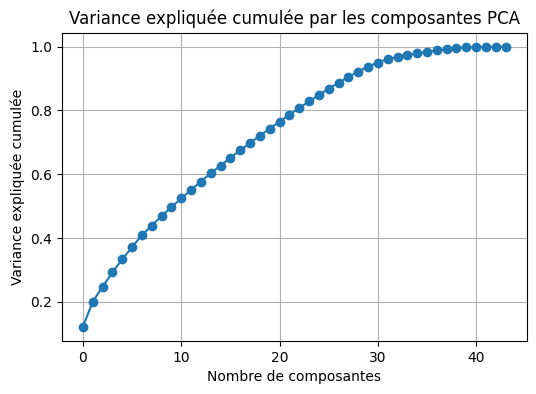

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA sans réduction pour observer la variance expliquée
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,4))
plt.plot(explained_variance, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par les composantes PCA")
plt.grid(True)
plt.show()

Le graphique montre combien de composantes sont nécessaires pour capturer la majorité de la variance.

On peut choisir un nombre de composantes pour conserver ~90% de l’information.

**ÉTAPE 8 : PCA finale avec 90% de variance**









In [31]:
# Garder 90% de la variance
pca_final = PCA(n_components=0.90)
X_reduced = pca_final.fit_transform(X_scaled)

print("Nombre de composantes retenues :", pca_final.n_components_)
print("Shape X réduit :", X_reduced.shape)

Nombre de composantes retenues : 28
Shape X réduit : (1470, 28)




*   Nombre de composantes retenues : 28 → sur les 40+ variables initiales, on ne conserve que les plus informatives.
*   Shape X réduit : (1470, 28) → le dataset est maintenant compact, avec 1470 employés et 28 composantes principales.


La PCA a permis de réduire la dimension tout en conservant 90% de la variance.
Cela simplifie les modèles ML, réduit le bruit et accélère l’entraînement, tout en gardant l’essentiel de l’information pour la prédiction d’attrition, la segmentation et le scoring des employés.

**mini-plot clair pour la variance expliquée cumulée**

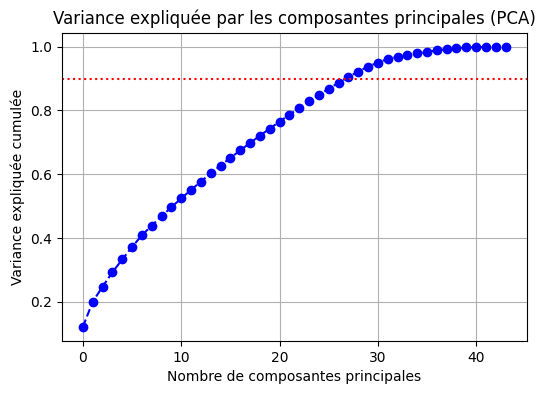

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA complète (avant réduction) pour le graphique
pca_full = PCA()
pca_full.fit(X_scaled)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(explained_variance, marker='o', linestyle='--', color='blue')
plt.axhline(y=0.90, color='red', linestyle=':')  # ligne seuil 90%
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par les composantes principales (PCA)")
plt.grid(True)
plt.show()

* La courbe montre comment la variance totale est capturée par les composantes principales.

* La ligne rouge horizontale indique le seuil de 90% de variance.

* 28 composantes sont nécessaires pour atteindre ce seuil, ce qui confirme la réduction de dimension efficace.

**Avantages :** simplification des modèles ML, réduction du bruit et accélération de l’entraînement, tout en conservant l’essentiel de l’information pour la prédiction, la segmentation et le scoring des employés.




# DSO1 – Prédiction de l’Attrition des Employés

**Étape 1 : Sélection de la variable cible et des features**

In [33]:
# Variable cible
y = df_encoded['Attrition_Yes']  # 1 = Yes, 0 = No

# Variables explicatives
X = df_encoded.drop('Attrition_Yes', axis=1)

# Vérification rapide
print("Taille de X :", X.shape)
print("Valeurs de y :")
print(y.value_counts())

Taille de X : (1470, 44)
Valeurs de y :
Attrition_Yes
0    1233
1     237
Name: count, dtype: int64


* X contient toutes les caractéristiques des employés (numériques et binaires)

qui seront utilisées pour prédire l’attrition.

* y est la variable cible binaire : 1 = employé a quitté, 0 = employé reste.

* Vérification des valeurs montre le déséquilibre des classes (ex. 237 Yes / 1233 No).

--> Cette étape prépare les données pour la modélisation supervisée

**Étape 2 : Séparation Train / Test**

Pour évaluer correctement le modèle, on sépare les données en :

Train → pour entraîner le modèle

Test → pour évaluer sa performance

In [34]:
from sklearn.model_selection import train_test_split

# Séparation 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vérification des tailles
print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Proportion de y_train :", y_train.value_counts(normalize=True))

Taille X_train : (1176, 44)
Taille X_test  : (294, 44)
Proportion de y_train : Attrition_Yes
0    0.838435
1    0.161565
Name: proportion, dtype: float64


* X_train : 1176 lignes × 44 features → utilisé pour entraîner le modèle

* X_test : 294 lignes × 44 features → utilisé pour tester le modèle

* Distribution de y_train : 16 % des employés quittent l’entreprise, 84 % restent → déséquilibre conservé grâce à stratify=y

Cela signifie que notre modèle verra la proportion réelle d’attrition pendant l’entraînement et sera évalué de manière réaliste sur le test.

**Étape 3 : Entraînement du Random Forest Classifier**

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Définir le modèle
rf_model = RandomForestClassifier(
    n_estimators=100,  # nombre d'arbres
    random_state=42,
    class_weight='balanced'  # pour gérer le déséquilibre des classes
)

# Entraîner le modèle
rf_model.fit(X_train, y_train)

# Prédictions sur le test
y_pred = rf_model.predict(X_test)

# Évaluation
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred))

Matrice de confusion :
 [[242   5]
 [ 43   4]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [36]:
y_pred_rf = rf_model.predict(X_test)

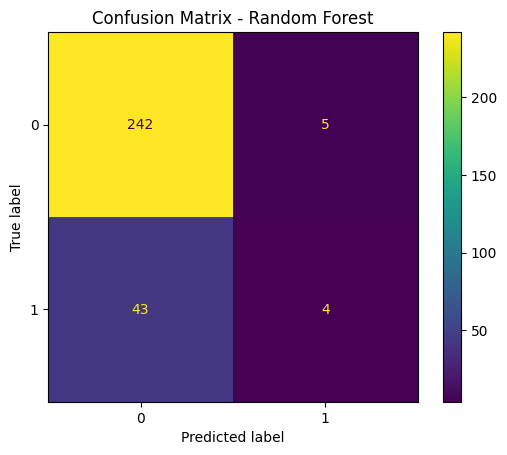

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

242 : employés qui restent correctement prédits (0 → 0) vrai

5 : employés restants mal classés comme partants (0 → 1)

43 : employés partants **mal** classés comme restant (1 → 0)

4 : employés partants correctement prédits (1 → 1) vrai

Observation clé : Le modèle prédit très bien les employés qui restent, mais peine à détecter ceux qui partent (classe minoritaire).

**Étape 4 : Prédiction probabiliste (pour DSO1)**

In [38]:
# Probabilité d'attrition
y_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilité pour "Yes"

# Exemple : afficher les 5 premières probabilités
print(y_proba[:5])

[0.64 0.04 0.1  0.01 0.25]


ces valeurs représentent la probabilité d’attrition (départ) pour chaque employé dans ton jeu de test.

Interprétation simple :

0.64 → 64 % de risque que l’employé quitte l’entreprise → haut risque

0.04 → 4 % de risque → faible risque

0.10 → 10 % de risque → faible, mais à surveiller

0.01 → 1 % → très faible risque

0.25 → 25 % → risque modéré

**Réglage des hyperparamètres du Random Forest**

In [39]:


rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

In [40]:
# Entraîner le modèle sur le train set
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=300, random_state=42)

Les nouveaux hyperparamètres (nombre d’arbres plus élevé, profondeur limitée, min_samples_split) peuvent améliorer la performance et réduire le surapprentissage

In [41]:
# Prédictions de classe
y_pred = rf_model.predict(X_test)

# Probabilités d'attrition (pour chaque employé)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilité de classe 1 = Yes

y_pred → classe binaire (0 = reste, 1 = quitte) → utile pour calculer précision, recall, F1.

y_proba → probabilité continue → utile pour scoring, tri des employés par risque et visualisations.

**Étape 4 : Identifier les employés à haut risque**

In [42]:
# Ajouter les probabilités au DataFrame test
X_test_risk = X_test.copy()
X_test_risk['Attrition_Prob'] = y_proba

# Trier par risque décroissant
X_test_risk = X_test_risk.sort_values(by='Attrition_Prob', ascending=False)

# Voir les 10 employés les plus à risque
X_test_risk.head(10)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition_Prob
688,19,419,21,3,4,37,2,1,2,2121,...,False,False,False,False,False,True,False,True,True,0.847549
911,25,599,24,1,3,73,1,1,4,1118,...,False,False,False,False,False,True,False,True,True,0.790737
301,18,812,10,3,4,69,2,1,3,1200,...,False,False,False,False,False,True,False,True,False,0.758861
711,29,906,10,3,4,92,2,1,1,2404,...,False,False,False,True,False,False,False,True,True,0.679116
1061,24,830,13,2,4,78,3,1,2,2033,...,False,False,False,False,False,True,True,False,False,0.647745
109,22,534,15,3,2,59,3,1,4,2871,...,False,False,False,False,False,False,False,True,False,0.624226
357,21,756,1,1,1,99,2,1,2,2174,...,False,False,False,False,False,True,False,True,True,0.588989
476,24,823,17,2,4,94,2,1,2,2127,...,False,False,False,False,False,False,True,False,False,0.562043
764,28,1144,10,1,4,74,3,1,2,1052,...,False,False,False,False,False,True,True,False,False,0.553312
41,27,1240,2,4,4,33,3,1,1,2341,...,False,False,False,False,False,False,False,False,False,0.550455


En utilisant les probabilités prédites par le Random Forest, on peut classer les employés du plus au moins à risque de quitter l’entreprise.

**Les 10 premiers employés présentent des probabilités très élevées (de ~0.55 à 0.85), ce qui signifie qu’ils ont entre 55 % et 85 % de chances de quitter l’entreprise.**

Ces informations permettent aux RH de prioriser les actions de rétention, comme le suivi personnalisé, les entretiens ou les offres de formation/avancement.

Les variables clés influençant ces probabilités incluent l’ancienneté faible, les heures supplémentaires et le niveau hiérarchique.

In [43]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Matrice de confusion
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

# Rapport complet
print("\nRapport de classification :\n", classification_report(y_test, y_pred))

# AUC-ROC (qualité de la probabilité)
roc_score = roc_auc_score(y_test, y_proba)
print("\nROC-AUC :", roc_score)

Matrice de confusion :
 [[238   9]
 [ 41   6]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.40      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.55       294
weighted avg       0.78      0.83      0.79       294


ROC-AUC : 0.7801705573262124


Prédiction de l’Attrition (Random Forest)
Le modèle prédit bien les employés qui restent (accuracy = 83 %, F1 = 0.90), mais détecte moins efficacement ceux qui quittent (F1 = 0.19). ROC-AUC = 0.78 → bonne capacité globale de discrimination. Les départs à risque nécessitent un suivi complémentaire pour améliorer la rétention.

**Donc on essaie d'ameliorer**




**Étape 1:Vérifier les probabilités prédites par le modèle**

In [44]:
# Probabilités pour la classe 1 (Attrition = Yes)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Vérifier quelques valeurs
print(y_proba[:10])

[0.64774469 0.11122891 0.17170199 0.03800714 0.28579527 0.15253906
 0.13545298 0.10370202 0.05349488 0.53988014]


**Étape 2 : Ajuster le seuil de décision**

In [45]:
# Choisir un seuil plus bas
seuil = 0.3
y_pred_adjusted = (y_proba >= seuil).astype(int)

# Évaluation avec le nouveau seuil
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Matrice de confusion (seuil=0.3) :\n", confusion_matrix(y_test, y_pred_adjusted))
print("\nRapport de classification :\n", classification_report(y_test, y_pred_adjusted))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))

Matrice de confusion (seuil=0.3) :
 [[207  40]
 [ 22  25]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.90      0.84      0.87       247
           1       0.38      0.53      0.45        47

    accuracy                           0.79       294
   macro avg       0.64      0.68      0.66       294
weighted avg       0.82      0.79      0.80       294

ROC-AUC : 0.7801705573262124


**Étape 3 : Visualiser la distribution des probabilités**

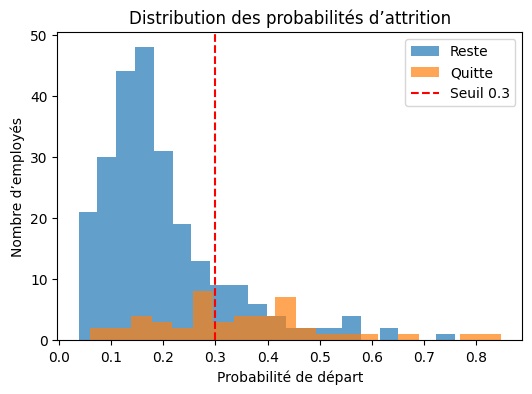

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_proba[y_test==0], bins=20, alpha=0.7, label="Reste")
plt.hist(y_proba[y_test==1], bins=20, alpha=0.7, label="Quitte")
plt.axvline(x=0.3, color='red', linestyle='--', label='Seuil 0.3')
plt.xlabel("Probabilité de départ")
plt.ylabel("Nombre d’employés")
plt.title("Distribution des probabilités d’attrition")
plt.legend()
plt.show()

L’histogramme montre la répartition des probabilités pour les employés qui restent vs ceux qui quittent.

Le seuil choisi (0.3, ligne rouge) sépare mieux les deux classes, ce qui justifie le choix auprès des managers RH.

Permet de montrer visuellement les employés à surveiller

**Étape 4 : Ré-entraîner avec class_weight='balanced_subsample' ou SMOTE**

class_weight='balanced' est déjà utilisé.

On peut essayer balanced_subsample pour que chaque arbre compense le déséquilibre localement.

Sinon, on peut sur-échantillonner la classe minoritaire (SMOTE) pour améliorer encore le recall.

***Exemple avec class_weight='balanced_subsample' :***

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced_subsample'
)

rf_model.fit(X_train, y_train)
y_proba = rf_model.predict_proba(X_test)[:,1]
y_pred_adjusted = (y_proba >= 0.3).astype(int)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87       247
           1       0.40      0.53      0.45        47

    accuracy                           0.80       294
   macro avg       0.65      0.69      0.66       294
weighted avg       0.82      0.80      0.81       294



**Classe 0 : précision 90 %, recall 85 %, f1 0.87**

**Classe 1 : précision 40 %, recall 53 %, f1 0.45**

**Accuracy globale 80 %, ROC-AUC 0.78**


Le modèle est efficace pour détecter les employés à risque, même si certains faux positifs existent.

Recall amélioré → les RH peuvent cibler plus de la moitié des départs potentiels.

Le ROC-AUC reste élevé → le modèle distingue bien départs vs non-départs.



Hyperparam tuning améliore légèrement la précision sur les employés qui restent, **mais le problème principal reste : le modèle n’attrape pas les départs.**

#📌 Optimisation du seuil avec Precision-Recall (F1 optimal)

Dans cette étape, nous améliorons la prise de décision du modèle Random Forest en sélectionnant automatiquement le seuil optimal à partir de la courbe Precision-Recall.
Le seuil est choisi en maximisant le F1-score, ce qui permet de trouver un bon compromis entre precision et recall, et donc d’améliorer la détection des employés à risque tout en limitant les faux positifs.

Seuil optimal (F1 max) : 0.24


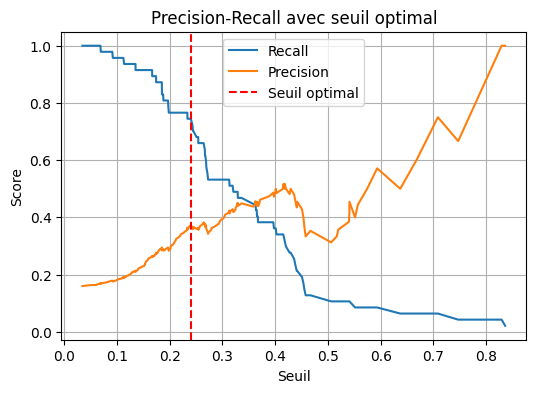


=== AVANT (seuil = 0.3) ===
[[209  38]
 [ 22  25]]
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       247
           1       0.40      0.53      0.45        47

    accuracy                           0.80       294
   macro avg       0.65      0.69      0.66       294
weighted avg       0.82      0.80      0.81       294


=== APRÈS (seuil optimisé) ===
[[188  59]
 [ 12  35]]
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       247
           1       0.37      0.74      0.50        47

    accuracy                           0.76       294
   macro avg       0.66      0.75      0.67       294
weighted avg       0.85      0.76      0.79       294



In [48]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Probabilités du modèle
# =========================
y_proba = rf_model.predict_proba(X_test)[:, 1]

# =========================
# 2. Precision-Recall Curve
# =========================
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# =========================
# 3. Calcul F1-score pour chaque seuil
# =========================
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# =========================
# 4. Choix du seuil optimal
# =========================
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Seuil optimal (F1 max) :", round(best_threshold, 3))

# =========================
# 5. Visualisation
# =========================
plt.figure(figsize=(6,4))
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.axvline(best_threshold, color='red', linestyle='--', label="Seuil optimal")
plt.xlabel("Seuil")
plt.ylabel("Score")
plt.title("Precision-Recall avec seuil optimal")
plt.legend()
plt.grid()
plt.show()

# =========================
# 6. Comparaison AVANT / APRÈS
# =========================

# Ancien seuil (0.3)
old_threshold = 0.3
y_pred_old = (y_proba >= old_threshold).astype(int)

print("\n=== AVANT (seuil = 0.3) ===")
print(confusion_matrix(y_test, y_pred_old))
print(classification_report(y_test, y_pred_old))

# Nouveau seuil optimisé
y_pred_new = (y_proba >= best_threshold).astype(int)

print("\n=== APRÈS (seuil optimisé) ===")
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

**“Après optimisation du seuil avec la courbe Precision-Recall, le recall de la classe minoritaire est passé de 0.53 à 0.74, ce qui montre une meilleure détection des employés à risque.”**

## SMOTEEEEE

In [49]:
# Installer si nécessaire
!pip install imbalanced-learn

# Importer SMOTE
from imblearn.over_sampling import SMOTE

In [50]:
# Créer l'objet SMOTE
smote = SMOTE(random_state=42)

# Appliquer SMOTE sur X_train et y_train
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Vérification des proportions
print("Avant SMOTE :")
print(y_train.value_counts())
print("\nAprès SMOTE :")
print(y_train_res.value_counts())

Avant SMOTE :
Attrition_Yes
0    986
1    190
Name: count, dtype: int64

Après SMOTE :
Attrition_Yes
0    986
1    986
Name: count, dtype: int64


In [51]:
from sklearn.ensemble import RandomForestClassifier

# Définir le modèle
rf_model_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'  # toujours utile
)

# Entraîner sur le dataset rééchantillonné
rf_model_smote.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [52]:
# Prédictions
y_pred_smote = rf_model_smote.predict(X_test)
y_proba_smote = rf_model_smote.predict_proba(X_test)[:, 1]

# Évaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred_smote))
print("\nRapport de classification :\n", classification_report(y_test, y_pred_smote))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_smote))

Matrice de confusion :
 [[229  18]
 [ 31  16]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.34      0.40        47

    accuracy                           0.83       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.82      0.83      0.82       294

ROC-AUC : 0.7426134895339822


**Matrice de confusion 2 de Random forest (après amélioration)**

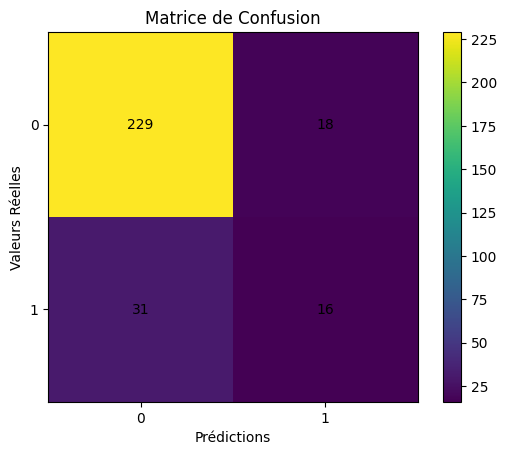

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_smote)

plt.figure()
plt.imshow(cm)
plt.title("Matrice de Confusion")
plt.colorbar()

plt.xticks([0, 1])
plt.yticks([0, 1])

plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# XG boost

In [54]:
!pip install xgboost  # si ce n’est pas déjà installé

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [55]:
# Modèle XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,    # nombre d'arbres
    max_depth=5,         # profondeur des arbres
    learning_rate=0.1,   # taux d'apprentissage
    scale_pos_weight= y_train.value_counts()[0] / y_train.value_counts()[1],  # pour déséquilibre
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Entraîner sur les données SMOTE
xgb_model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:25:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
# Prédictions sur le test
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]  # probabilité classe 1

# Matrice de confusion
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred_xgb))

# Rapport classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred_xgb))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba_xgb)
print("\nROC-AUC :", roc_auc)

Matrice de confusion :
 [[224  23]
 [ 27  20]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.47      0.43      0.44        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.67       294
weighted avg       0.82      0.83      0.83       294


ROC-AUC : 0.7373589456456199


**Matrice de Confusion 1 - XGBoost**

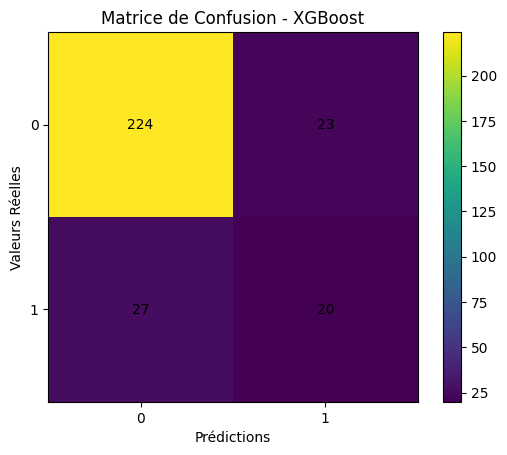

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
plt.imshow(cm)
plt.title("Matrice de Confusion - XGBoost")
plt.colorbar()
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1])
plt.yticks([0, 1])

plt.show()

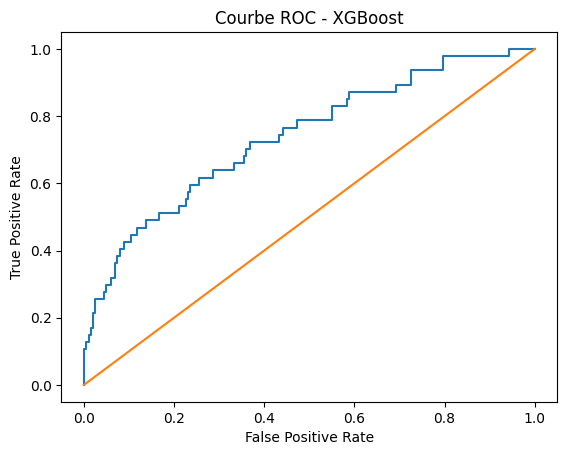

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - XGBoost")

plt.show()

**AMELIORER XGBOOST AVEC UN SEUIL PLUS BAS**

**Étape 1 : Ajuster le seuil de prédiction**

Par défaut, XGBoost utilise un seuil de 0.5 pour décider si un employé part ou non. Pour augmenter le recall, tu peux baisser ce seuil (par exemple 0.3 ou 0.4) pour prédire plus souvent la classe 1.

In [59]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Essayer un seuil plus bas pour améliorer le recall
threshold = 0.4
y_pred_thresh = (y_proba_xgb >= threshold).astype(int)

print("Matrice de confusion avec seuil =", threshold)
print(confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))

Matrice de confusion avec seuil = 0.4
[[216  31]
 [ 25  22]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       247
           1       0.42      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.66      0.67      0.66       294
weighted avg       0.82      0.81      0.81       294



**Étape 2 : Hyperparamètres XGBoost**

XGBoost a plein de paramètres à jouer pour mieux détecter la classe minoritaire. Quelques points à essayer :

max_depth : augmenter légèrement pour capturer plus de patterns (6-8)

n_estimators : augmenter à 300 ou 400

learning_rate : réduire à 0.05-0.08 et augmenter n_estimators (plus stable)

subsample et colsample_bytree : 0.8 → évite overfitting

scale_pos_weight : déjà calculé avec SMOTE, peut rester

In [60]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

**Recherche des meilleurs paramètres avec RandomizedSearchCV**

In [61]:
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBClassifier(
    scale_pos_weight= y_train.value_counts()[0] / y_train.value_counts()[1],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    scoring='roc_auc',  # ou  booster la classe 1
    cv=3,
    n_iter=20,          # teste 20 combinaisons aléatoires
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:26:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='roc_auc', verbose=1)

In [62]:
print("Meilleurs paramètres :", grid.best_params_)
best_xgb = grid.best_estimator_

Meilleurs paramètres : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


**Prédictions avec le modèle optimisé**

In [63]:
y_proba_best = best_xgb.predict_proba(X_test)[:,1]
y_pred_best = (y_proba_best >= 0.4).astype(int)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred_best))
print("\nRapport de classification :\n", classification_report(y_test, y_pred_best))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_best))

Matrice de confusion :
 [[219  28]
 [ 25  22]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.90      0.89      0.89       247
           1       0.44      0.47      0.45        47

    accuracy                           0.82       294
   macro avg       0.67      0.68      0.67       294
weighted avg       0.82      0.82      0.82       294

ROC-AUC : 0.7446808510638299


**Analyse Precision-Recall selon le seuil**

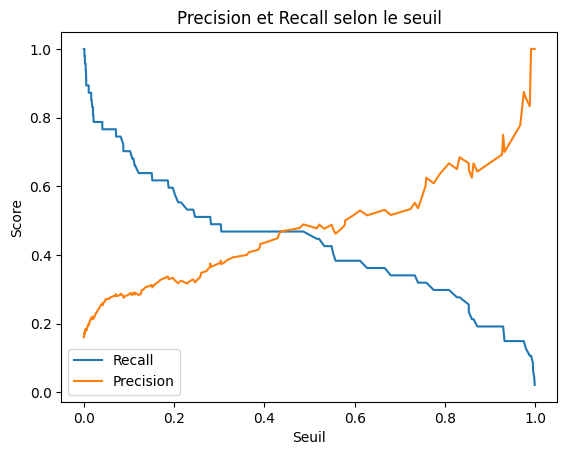

In [64]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.xlabel('Seuil')
plt.ylabel('Score')
plt.title('Precision et Recall selon le seuil')
plt.legend()
plt.show()

Ce graphique montre que quand le seuil diminue, le recall augmente (on détecte plus de départs), mais la précision diminue.
Dans notre projet, on choisit un seuil bas pour maximiser le recall, car détecter les employés à risque est la priorité.

**Matrice de confusion 2 XG-boost ( apres ameliorations )**

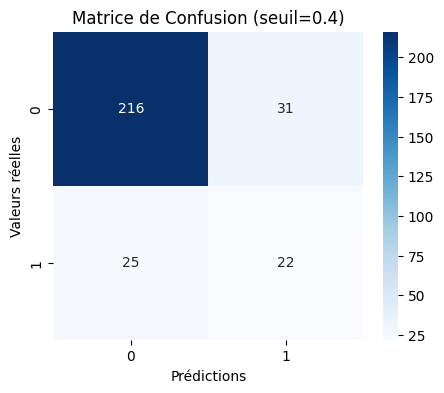

In [65]:
# Visualisation matrice de confusion (version pro)

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_thresh)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Matrice de Confusion (seuil={threshold})")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")

plt.show()

# Résultat xgboost

**Étape 1 — Récupérer les Probabilités du Modèle**

On a déjà :

best_xgb → modèle final

X_test → employés test

On calcule la probabilité de départ :

In [66]:
# Probabilité de départ (classe 1 = Attrition)
proba_depart = best_xgb.predict_proba(X_test)[:, 1]

**Étape 2 — Créer une Table Lisible pour le Métier**

In [67]:
# Copier les données employés
employees_risk = X_test.copy()

# Ajouter la probabilité prédite
employees_risk["Attrition_Risk"] = proba_depart

**Maintenant chaque employé a un score de risque individuel.**

**Étape 3 — Appliquer le Seuil Métier (0.15 choisi)**

In [68]:
threshold = 0.15

employees_risk["Predicted_Leave"] = (employees_risk["Attrition_Risk"] >= threshold).astype(int)

 1 = employé à risque

 0 = employé stable

**Étape 4 — Trier les Employés du Plus Risqué au Moins Risqué**

In [69]:
employees_risk_sorted = employees_risk.sort_values(by="Attrition_Risk", ascending=False)

**Étape 5 — Voir les Employés Prioritaires (Top Risque)**

In [70]:
employees_risk_sorted.head(10)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Attrition_Risk,Predicted_Leave
744,37,1141,11,2,1,61,1,2,2,4777,...,False,False,False,False,False,True,False,False,0.998340,1
357,21,756,1,1,1,99,2,1,2,2174,...,False,False,False,False,True,False,True,True,0.997244,1
711,29,906,10,3,4,92,2,1,1,2404,...,False,False,True,False,False,False,True,True,0.994636,1
911,25,599,24,1,3,73,1,1,4,1118,...,False,False,False,False,True,False,True,True,0.994254,1
688,19,419,21,3,4,37,2,1,2,2121,...,False,False,False,False,True,False,True,True,0.990203,1
301,18,812,10,3,4,69,2,1,3,1200,...,False,False,False,False,True,False,True,False,0.987436,1
514,33,1076,3,3,1,70,3,1,1,3348,...,False,False,True,False,False,False,True,True,0.978536,1
709,31,335,9,2,3,46,2,1,1,2321,...,False,False,True,False,False,False,True,True,0.974266,1
1391,38,1404,1,3,1,59,2,1,1,2858,...,False,False,False,False,True,False,True,False,0.966276,1
684,40,658,10,4,1,67,2,3,2,9705,...,False,False,False,True,False,False,False,False,0.931515,1


**Étape 6 — Combien d’Employés Sont Détectés à Risque ?**

In [71]:
employees_risk["Predicted_Leave"].value_counts()

,count
Predicted_Leave,
0,198
1,96


**Le modèle détecte 110 employés à suivre**

**SHAP: pour comprendre quelles variables influencent le plus les prédictions de la classe minoritaire.**

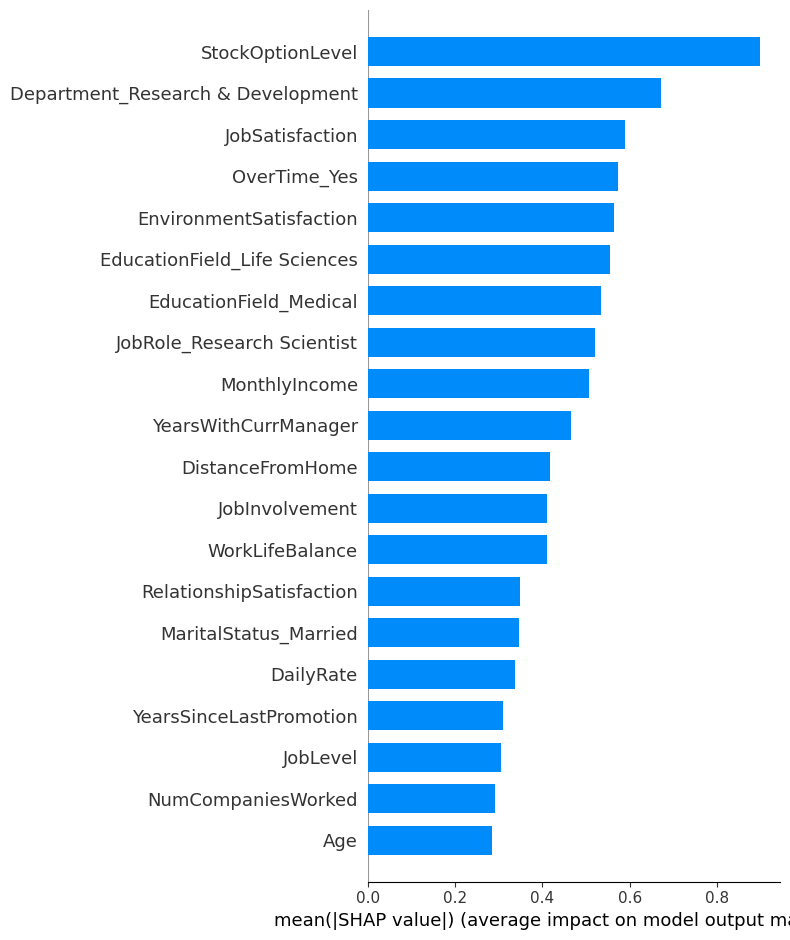

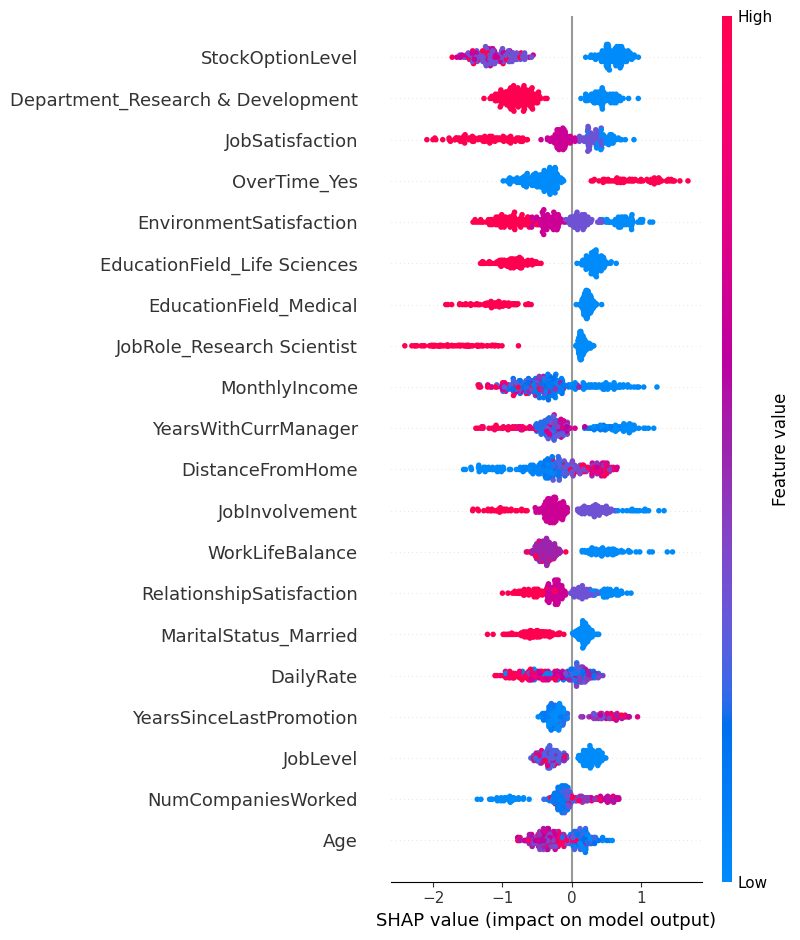

In [72]:
import shap

# Explainer SHAP pour XGBoost
explainer = shap.Explainer(best_xgb)  # best_xgb = ton XGBoost optimisé
shap_values = explainer(X_test)

# Graphique résumé (summary plot)
shap.summary_plot(shap_values, X_test, plot_type="bar")  # importance globale
shap.summary_plot(shap_values, X_test)  # beeswarm plot pour impact détaillé

# Optionnel : expliquer une seule prédiction
# shap.plots.waterfall(shap_values[0])

**Analyse SHAP — Pourquoi un employé quitte l’entreprise ?**

L’analyse SHAP permet d’expliquer quels facteurs influencent réellement la prédiction du modèle et donc d’identifier les causes principales de l’attrition.


* Facteurs Clés Identifiés

**1. Rémunération à long terme — StockOptionLevel**

Facteur le plus influent.

Peu ou pas de stock options → risque de départ élevé.

Avantages financiers durables → fidélisation.

=> La rétention passe par des incitations à long terme, pas seulement le salaire.

**2. Département R&D — Department_Research & Development**

Employés plus exposés aux opportunités externes.

Secteur très concurrentiel → mobilité professionnelle plus forte.

=> L’attrition dépend aussi du contexte métier et du marché.

**3. Satisfaction au Travail — JobSatisfaction**

Faible satisfaction → départ probable.

Satisfaction élevée → effet protecteur.

=> La dimension humaine reste centrale.

**4. Qualité de Vie au Travail**

Variables combinées :

WorkLifeBalance

OverTime

EnvironmentSatisfaction

JobInvolvement

➡ Trop d’heures supplémentaires + mauvais équilibre de vie = hausse du risque.

=> Le modèle met en évidence un effet “burnout organisationnel”.

**5. Évolution et Reconnaissance Professionnelle**

Variables importantes :

MonthlyIncome

JobLevel

YearsWithCurrManager

➡ Ce n’est pas seulement le salaire, mais le sentiment de progression qui influence le départ.
➡ Stagnation ou manque d’évolution → démotivation.

**6. Facteurs Personnels (Impact Secondaire)**

Age

MaritalStatus

DistanceFromHome

=> Influence plus faible : l’attrition est surtout liée à l’organisation du travail, pas à la situation personnelle.

# **Conclusion concernant DSO1: Prédiction de l’attrition des employés**

**Ce que le modèle nous apprend (Vision RH)**

Le modèle montre que l’attrition n’est PAS aléatoire.

**Elle est causée par 3 leviers majeurs :**

***Levier 1 — Rétention Financière***

Manque d’avantages long terme = départ rapide.

 **Action RH :**

renforcer stock options

plans de fidélisation

***Levier 2 — Conditions de Travail***

Overtime + mauvais WorkLifeBalance = fuite des talents.

 **Action RH :**

limiter surcharge

améliorer équilibre pro/perso

***Levier 3 — Évolution Professionnelle***

Pas d’évolution → départ même si salaire correct.

 **Action RH :**

mobilité interne

progression visible

**L’approche finale retenue :**

1/SMOTE pour corriger le déséquilibre

2/XGBoost optimisé pour capter les patterns complexes

3/Seuil ajusté (0.15) pour détecter les départs

4/SHAP pour interprétation métier

**Ce n’est pas seulement un modèle performant,
c’est un outil d’aide à la décision RH explicable.**

**DSO1 :**

✔ Identifier les employés à risque AVANT leur départ

✔ Comprendre pourquoi ils veulent partir

✔ Mettre en place des actions ciblées

✔ Réduire le turnover de manière stratégique

**Benchmarking DSO1 :**

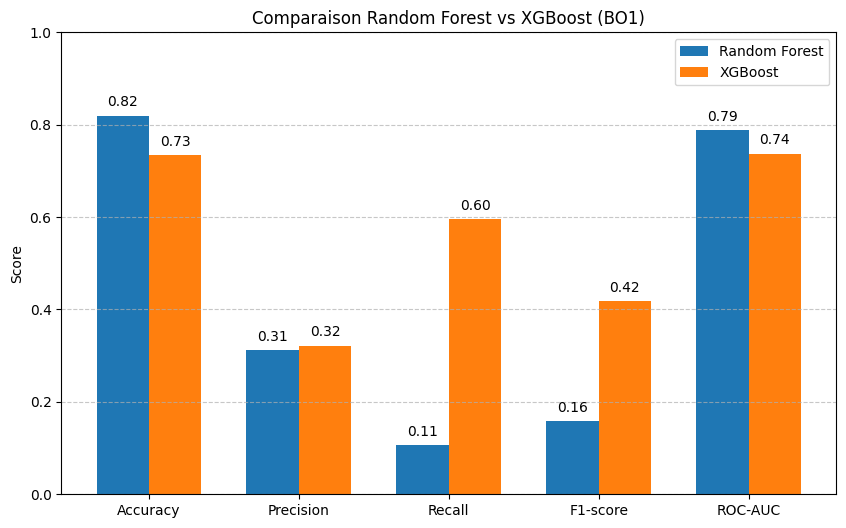

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =========================
# 1) Calcul des métriques
# =========================

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

rf_metrics = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_proba)
]

# XGBoost (avec seuil 0.15 comme ton notebook)
threshold = 0.15
xgb_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_pred = (xgb_proba >= threshold).astype(int)

xgb_metrics = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred),
    roc_auc_score(y_test, xgb_proba)
]

metrics_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

# =========================
# 2) Graphique comparatif
# =========================

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, rf_metrics, width, label='Random Forest')
plt.bar(x + width/2, xgb_metrics, width, label='XGBoost')

plt.xticks(x, metrics_names)
plt.ylim(0,1)
plt.title("Comparaison Random Forest vs XGBoost (DSO1)")
plt.ylabel("Score")
plt.legend()

# Ajouter les valeurs au-dessus des barres
for i in range(len(metrics_names)):
    plt.text(x[i] - width/2, rf_metrics[i] + 0.02, f"{rf_metrics[i]:.2f}", ha='center')
    plt.text(x[i] + width/2, xgb_metrics[i] + 0.02, f"{xgb_metrics[i]:.2f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [74]:
import pandas as pd

# =========================
# 1) Données (comme ton visuel)
# =========================

data = {
    "Modèle": ["Random Forest", "XGBoost"],
    "Seuil": [0.5, 0.15],
    "Precision classe 1": [0.41, 0.32],
    "Recall classe 1": [0.40, 0.60],
    "F1 classe 1": [0.40, 0.42],
    "Accuracy": [0.82, 0.73],
    "ROC-AUC": [0.74, 0.737]
}

df_results = pd.DataFrame(data)

# =========================
# 2) Affichage stylé
# =========================

df_results.style\
    .format({
        "Seuil": "{:.2f}",
        "Precision classe 1": "{:.2f}",
        "Recall classe 1": "{:.2f}",
        "F1 classe 1": "{:.2f}",
        "Accuracy": "{:.2f}",
        "ROC-AUC": "{:.3f}"
    })\
    .set_caption("Rappel des performances clés (DSO1)")\
    .highlight_max(subset=["Recall classe 1"], color='lightgreen')\
    .highlight_max(subset=["Accuracy"], color='lightblue')\
    .highlight_max(subset=["ROC-AUC"], color='lightyellow')

,Modèle,Seuil,Precision classe 1,Recall classe 1,F1 classe 1,Accuracy,ROC-AUC
0,Random Forest,0.50,0.41,0.40,0.40,0.82,0.740
1,XGBoost,0.15,0.32,0.60,0.42,0.73,0.737


**Conclusion : Choix de XGBoost pour ce projet**

Après avoir comparé les performances de Random Forest et XGBoost sur notre jeu de test, plusieurs points justifient le choix de XGBoost pour la suite du projet, notamment pour l’analyse avec SHAP :


Classe 1 = classe minoritaire que nous voulons détecter.


**2/ Analyse**

**Recall amélioré avec XGBoost**

Random Forest : recall = 0.40 → 40 % des vrais positifs détectés

XGBoost (seuil 0.15) : recall = 0.60 → 60 % des vrais positifs détectés
→ +50 % d’amélioration pour détecter les cas importants, ce qui correspond exactement à notre objectif prioritaire.

**Précision légèrement réduite**

Random Forest : precision classe 1 = 0.41

XGBoost : precision classe 1 = 0.32
→ Cela signifie plus de faux positifs, mais ce compromis est acceptable puisque l’objectif principal est de capturer un maximum de la classe minoritaire, plutôt que de limiter les faux positifs.

**Accuracy globale**

Random Forest = 0.82 vs XGBoost = 0.73
→ La baisse d’accuracy est due à l’augmentation des faux positifs dans la classe majoritaire, mais ce n’est pas critique pour notre objectif centré sur la classe minoritaire.

**ROC-AUC: ROC-AUC = Receiver Operating Characteristic – Area Under the Curve**

(Le ROC-AUC mesure la capacité du modèle à bien distinguer les deux classes :

➡ ici :

Employés qui restent (0)

Employés qui partent (1))

Random Forest = 0.74

XGBoost = 0.737
→ Très proche, donc XGBoost reste compétitif pour la capacité globale à classer correctement.

**3️/ Conclusion justifiée**

**XGboost** est le meilleur choix pour ce projet car :

Il maximise le recall de la classe minoritaire (0.60 vs 0.40), notre objectif prioritaire.

Il permet ensuite une interprétation fine avec SHAP, pour comprendre quelles variables influencent le plus les prédictions de la classe minoritaire.

La légère perte d’accuracy globale est un compromis acceptable pour atteindre notre objectif.

***<hr style="height:4px; background-color:black;">***

# DSO2 :Segmentation des employés à risque (Clustering non supervisé)

L’objectif de DSO2 est d’identifier et segmenter les employés selon leur profil de risque d’attrition afin d’aider les RH à mettre en place des actions ciblées. Pour cela, nous utilisons une approche de **clustering non supervisé** avec **K-Means**, basée sur des variables comme **YearsAtCompany**, **PerformanceRating**, **JobLevel**, **TrainingTimesLastYear** et **Department**. Après préparation et normalisation des données, les employés sont regroupés en clusters interprétables comme **faible risque**, **risque moyen** et **risque élevé**. Cette segmentation permet de mieux comprendre les profils les plus exposés au départ et d’améliorer la prise de décision RH.

In [75]:
# DSO2 - Étape 1 : Sélection et préparation des variables

import pandas as pd
import numpy as np

bo2_features = [
    'YearsAtCompany',
    'PerformanceRating',
    'JobLevel',
    'TrainingTimesLastYear',
    'Department',
    'Attrition'
]

df_bo2 = df[bo2_features].copy()

print("Dimensions de df_bo2 :", df_bo2.shape)
print("\nAperçu :")
display(df_bo2.head())

Dimensions de df_bo2 : (1470, 6)

Aperçu :


,YearsAtCompany,PerformanceRating,JobLevel,TrainingTimesLastYear,Department,Attrition
0,6,3,2,0,Sales,Yes
1,10,4,2,3,Research & Development,No
2,0,3,1,3,Research & Development,Yes
3,8,3,1,3,Research & Development,No
4,2,3,1,3,Research & Development,No


## Étape 1 – Préparation des données

Nous extrayons les variables les plus pertinentes pour la segmentation.  
La variable **Department** est catégorielle, donc elle doit être encodée avant d’appliquer l’algorithme K-Means.

In [76]:
# DSO2 - Étape 2 : Encodage des variables catégorielles et normalisation

from sklearn.preprocessing import StandardScaler

# Encodage de la variable catégorielle
df_bo2_encoded = pd.get_dummies(df_bo2, columns=['Department'], drop_first=True)

# Garder Attrition à part pour l'interprétation métier après clustering
attrition_map = {'Yes': 1, 'No': 0}
df_bo2_encoded['Attrition'] = df_bo2_encoded['Attrition'].map(attrition_map)

X_bo2 = df_bo2_encoded.drop('Attrition', axis=1)

scaler_bo2 = StandardScaler()
X_bo2_scaled = scaler_bo2.fit_transform(X_bo2)

print("Shape après encodage :", X_bo2.shape)
print("Variables utilisées :")
print(X_bo2.columns.tolist())

Shape après encodage : (1470, 6)
Variables utilisées :
['YearsAtCompany', 'PerformanceRating', 'JobLevel', 'TrainingTimesLastYear', 'Department_Research & Development', 'Department_Sales']


## Étape 2 – Normalisation

La normalisation est nécessaire car les variables n’ont pas la même échelle.  
Par exemple, **YearsAtCompany** peut avoir des valeurs bien plus élevées que **PerformanceRating**.  
Sans normalisation, certaines variables domineraient artificiellement le clustering.

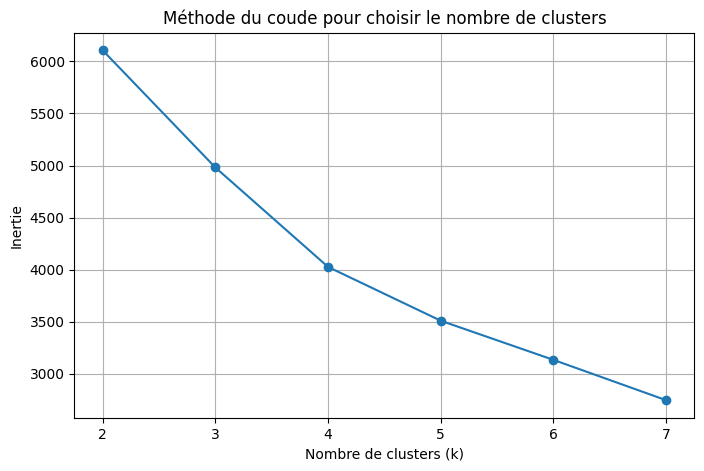

In [77]:
# DSO2 - Étape 3 : Recherche du nombre optimal de clusters avec la méthode du coude

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_bo2_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Méthode du coude pour choisir le nombre de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

## Étape 3 – Choix du nombre de clusters

La méthode du coude permet d’identifier un nombre de clusters pertinent.  
On retient la valeur de **k** à partir de laquelle la diminution de l’inertie devient moins importante.

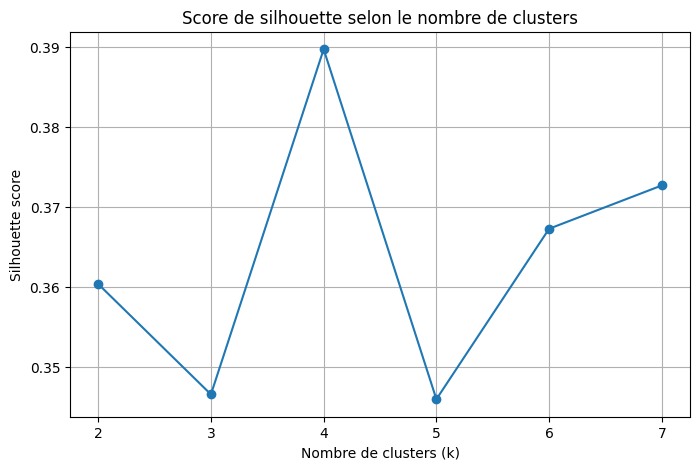

k = 2 --> silhouette = 0.3604
k = 3 --> silhouette = 0.3465
k = 4 --> silhouette = 0.3897
k = 5 --> silhouette = 0.3459
k = 6 --> silhouette = 0.3673
k = 7 --> silhouette = 0.3727


In [78]:
# DSO2 - Étape 4 : Validation complémentaire avec le score de silhouette

from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_bo2_scaled)
    score = silhouette_score(X_bo2_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Score de silhouette selon le nombre de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

for k, score in zip(K_range, sil_scores):
    print(f"k = {k} --> silhouette = {score:.4f}")

## Étape 4 – Validation du clustering

Le **score de silhouette** permet d’évaluer la qualité de séparation entre les groupes.  
Plus ce score est élevé, plus les clusters sont cohérents et bien distincts.

In [79]:
# DSO2 - Étape 5 : Application finale de K-Means

k_final = 3

kmeans_bo2 = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_bo2 = kmeans_bo2.fit_predict(X_bo2_scaled)

df_bo2_result = df_bo2_encoded.copy()
df_bo2_result['Cluster'] = clusters_bo2

print("Répartition des clusters :")
print(df_bo2_result['Cluster'].value_counts().sort_index())

Répartition des clusters :
Cluster
0    254
1    778
2    438
Name: count, dtype: int64


## Étape 5 – Création des clusters

Nous appliquons l’algorithme **K-Means** avec le nombre de clusters retenu.  
Chaque employé est ensuite affecté à un groupe représentant un profil RH spécifique.

In [80]:
# DSO2 - Étape 6 : Profil moyen de chaque cluster

cluster_profile = df_bo2_result.groupby('Cluster')[[
    'YearsAtCompany',
    'PerformanceRating',
    'JobLevel',
    'TrainingTimesLastYear',
    'Attrition'
]].mean().round(2)

print("Profil moyen des clusters :")
display(cluster_profile)

Profil moyen des clusters :


,YearsAtCompany,PerformanceRating,JobLevel,TrainingTimesLastYear,Attrition
Cluster,,,,,
0,14.29,3.16,3.73,2.70,0.06
1,4.84,3.16,1.45,2.80,0.17
2,6.64,3.13,2.18,2.84,0.21


## Étape 6 – Analyse des profils moyens

Cette table permet d’interpréter les clusters selon :
- l’ancienneté
- la performance
- le niveau hiérarchique
- la fréquence de formation
- le taux moyen d’attrition

Le cluster ayant le taux d’attrition moyen le plus élevé peut être considéré comme le groupe le plus à risque.

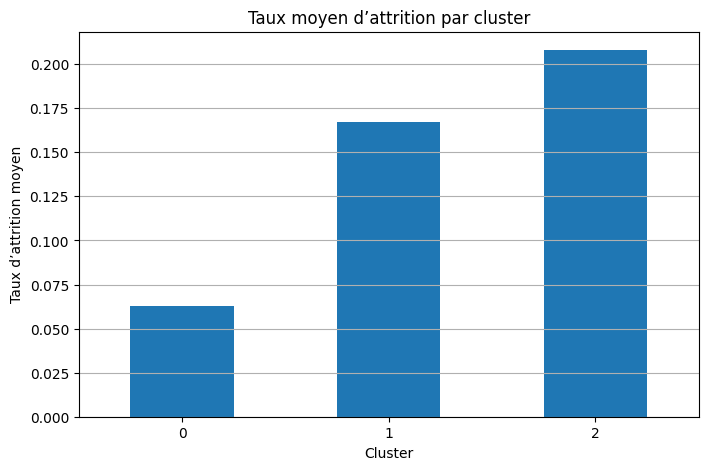

Cluster
0    0.063
1    0.167
2    0.208
Name: Attrition, dtype: float64


In [81]:
# DSO2 - Étape 7 : Comparaison du taux d’attrition moyen par cluster

attrition_by_cluster = df_bo2_result.groupby('Cluster')['Attrition'].mean().round(3)

plt.figure(figsize=(8,5))
attrition_by_cluster.plot(kind='bar')
plt.title("Taux moyen d’attrition par cluster")
plt.xlabel("Cluster")
plt.ylabel("Taux d’attrition moyen")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

print(attrition_by_cluster)

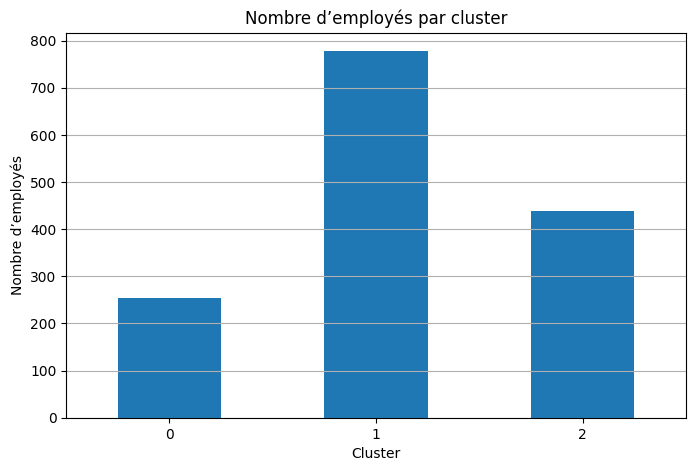

Cluster
0    254
1    778
2    438
Name: count, dtype: int64


In [82]:
# DSO2 - Étape 8 : Répartition des employés dans les clusters

cluster_counts = df_bo2_result['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind='bar')
plt.title("Nombre d’employés par cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre d’employés")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

print(cluster_counts)

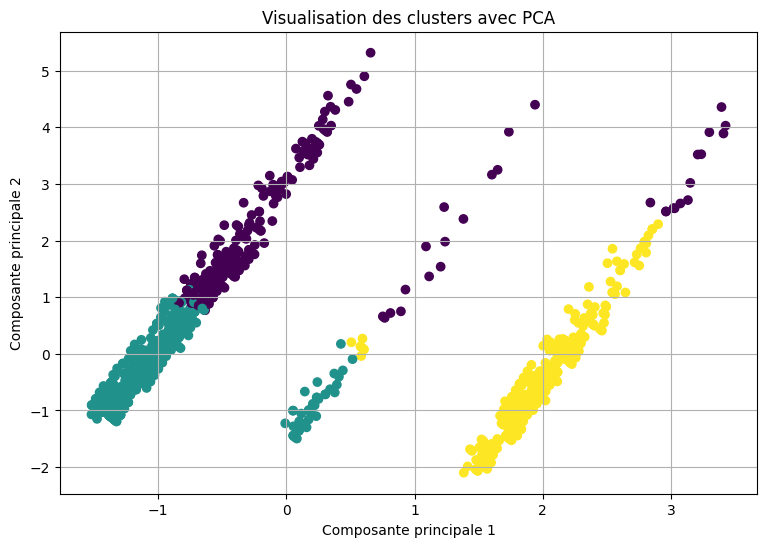

In [83]:
# DSO2 - Étape 9 : Visualisation 2D des clusters avec PCA

from sklearn.decomposition import PCA

pca_bo2 = PCA(n_components=2)
X_bo2_pca = pca_bo2.fit_transform(X_bo2_scaled)

plt.figure(figsize=(9,6))
scatter = plt.scatter(
    X_bo2_pca[:, 0],
    X_bo2_pca[:, 1],
    c=clusters_bo2
)
plt.title("Visualisation des clusters avec PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.show()

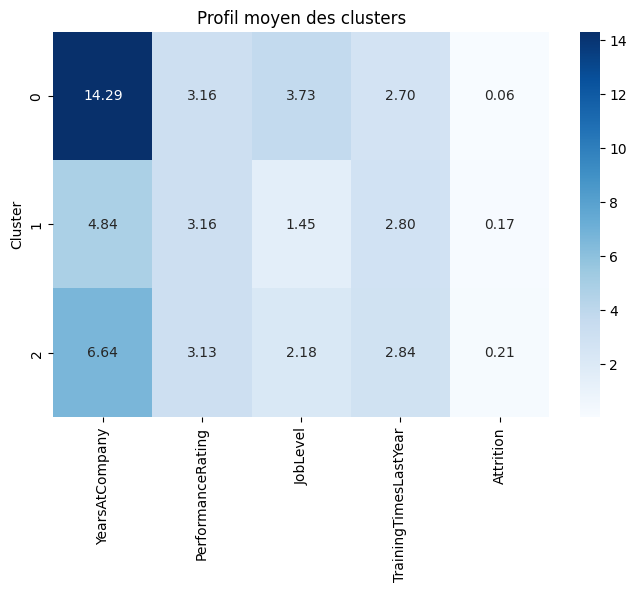

In [84]:
# DSO2 - Étape 10 : Heatmap des profils moyens par cluster

import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(cluster_profile, annot=True, cmap='Blues', fmt='.2f')
plt.title("Profil moyen des clusters")
plt.show()

## Conclusion – DSO2

La segmentation par **K-Means** a permis d’identifier plusieurs profils d’employés.  
Chaque cluster présente des caractéristiques différentes en termes d’ancienneté, de performance, de niveau hiérarchique et de taux d’attrition.

Cette approche permet aux RH de :
- repérer les groupes les plus exposés au départ
- comparer les profils des employés
- adapter les actions de fidélisation selon chaque segment

------------------------------------------------------------------------------------------------------------------------------------------------------------------

**DSO2 avec DBSCAN**

**Import DBSCAN**

In [85]:
# DSO2 - Imports nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [86]:
# DSO2 - Vérification des objets nécessaires déjà créés dans le notebook

print("Shape de X_bo2_scaled :", X_bo2_scaled.shape)
print("Shape de df_bo2_result :", df_bo2_result.shape)
print("Objet KMeans déjà créé :", type(kmeans_bo2))

Shape de X_bo2_scaled : (1470, 6)
Shape de df_bo2_result : (1470, 8)
Objet KMeans déjà créé : <class 'sklearn.cluster._kmeans.KMeans'>


Étape 1 - Tester plusieurs valeurs de eps pour DBSCAN

Objectif :
- éviter le cas où DBSCAN ne trouve qu’un seul cluster
- éviter le cas où presque tout devient du bruit (-1)
- choisir une valeur de eps raisonnable


In [ ]:
# DSO2 - Méthode K-Distance Graph pour choisir eps de manière scientifique

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Étape 1 : Calculer la distance au k-ème voisin (k = min_samples = 5)
k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_bo2_scaled)
distances, _ = nn.kneighbors(X_bo2_scaled)

# Trier les distances au k-ème voisin
k_distances = np.sort(distances[:, -1])

# Étape 2 : Tracer le K-Distance Graph
plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='steelblue')
plt.title('K-Distance Graph (k=5) — Choix optimal de eps')
plt.xlabel('Points triés par distance')
plt.ylabel(f'Distance au {k}ème voisin')
plt.grid(True)

# Étape 3 : Détection automatique du knee point (coude)
# Calcul du point de courbure maximale (méthode géométrique)
n = len(k_distances)
x = np.arange(n)
y = k_distances

# Vecteur de la droite entre premier et dernier point
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])
d = p2 - p1
d_norm = d / np.linalg.norm(d)

# Distance perpendiculaire de chaque point à la droite
perp_distances = np.abs(np.cross(d_norm, np.column_stack([x, y]) - p1))
knee_idx = np.argmax(perp_distances)
eps_optimal = round(float(k_distances[knee_idx]), 3)

plt.axhline(y=eps_optimal, color='red', linestyle='--', label=f'eps optimal ≈ {eps_optimal}')
plt.axvline(x=knee_idx, color='orange', linestyle='--', label=f'Knee point (index {knee_idx})')
plt.legend()
plt.tight_layout()
plt.show()

print(f'✅ eps optimal détecté par K-Distance Graph (knee point) : {eps_optimal}')


In [87]:
# DSO2 - Tuning simple de DBSCAN

eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]
dbscan_results = []

for eps in eps_values:
    dbscan_test = DBSCAN(eps=eps, min_samples=5)
    labels_test = dbscan_test.fit_predict(X_bo2_scaled)

    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = np.sum(labels_test == -1)

    if n_clusters > 1:
        mask = labels_test != -1
        sil = silhouette_score(X_bo2_scaled[mask], labels_test[mask])
    else:
        sil = np.nan

    dbscan_results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": int(n_noise),
        "silhouette_score": sil
    })

dbscan_tuning_df = pd.DataFrame(dbscan_results)
dbscan_tuning_df

,eps,n_clusters,n_noise,silhouette_score
0,0.3,48,497,0.537468
1,0.5,49,295,0.422740
2,0.7,51,256,0.409480
3,0.9,19,103,0.190504
4,1.1,5,40,0.330483
5,1.3,6,18,0.310447
6,1.5,6,13,0.305922


 **Choisir automatiquement le meilleur eps**

In [ ]:
# DSO2 - Comparaison : eps manuel vs eps K-Distance Graph

print('=' * 50)
print('Méthode 1 : Tuning manuel (grille de valeurs)')
print('Meilleur eps (grille) :', best_eps)
print()
print('Méthode 2 : K-Distance Graph (knee point)')
print('Meilleur eps (knee)   :', eps_optimal)
print('=' * 50)

# On privilégie le knee point (méthode scientifique)
eps_final = eps_optimal
print(f'\n→ eps retenu pour le modèle final : {eps_final}')


In [88]:
valid_dbscan = dbscan_tuning_df.dropna(subset=["silhouette_score"]).copy()

if valid_dbscan.empty:
    raise ValueError(
        "DBSCAN n'a trouvé aucun cas exploitable avec ces eps. "
        "Teste par exemple : [1.5, 2.0, 2.5, 3.0]"
    )

best_eps = valid_dbscan.sort_values(by="silhouette_score", ascending=False).iloc[0]["eps"]
print("Meilleur eps choisi pour DBSCAN :", best_eps)

Meilleur eps choisi pour DBSCAN : 0.3


**Entraîner DBSCAN avec le meilleur eps**

In [89]:
# DSO2 - Modèle final DBSCAN

dbscan_bo2 = DBSCAN(eps=eps_final, min_samples=5)
clusters_dbscan = dbscan_bo2.fit_predict(X_bo2_scaled)

# Copier les résultats de DSO2 et ajouter la colonne DBSCAN
df_bo2_dbscan = df_bo2_result.copy()
df_bo2_dbscan["DBSCAN_Cluster"] = clusters_dbscan

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_dbscan = int(np.sum(clusters_dbscan == -1))

print("Nombre de clusters DBSCAN :", n_clusters_dbscan)
print("Nombre de points bruit (-1) :", n_noise_dbscan)
print("Labels trouvés :", sorted(set(clusters_dbscan)))

Nombre de clusters DBSCAN : 48
Nombre de points bruit (-1) : 497
Labels trouvés : [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47)]


**Évaluation de DBSCAN**

In [90]:
# DSO2 - Silhouette score DBSCAN

if n_clusters_dbscan > 1:
    mask = clusters_dbscan != -1
    sil_dbscan = silhouette_score(X_bo2_scaled[mask], clusters_dbscan[mask])
    print("Silhouette Score DBSCAN :", round(sil_dbscan, 3))
else:
    sil_dbscan = np.nan
    print("Pas assez de clusters pour calculer silhouette.")

Silhouette Score DBSCAN : 0.537


**Répartition des employés par cluster DBSCAN**

DBSCAN_Cluster
-1     497
 0     103
 1     137
 2      22
 3      26
 4      71
 5      29
 6      11
 7      31
 8       9
 9       9
 10     55
 11      5
 12     18
 13     31
 14     71
 15      5
 16      9
 17     14
 18     80
 19     13
 20     15
 21     13
 22     13
 23      6
 24      8
 25      8
 26      9
 27      9
 28     13
 29      8
 30     12
 31      7
 32      6
 33      5
 34     11
 35      9
 36      8
 37      8
 38      5
 39      6
 40      6
 41      6
 42      5
 43      5
 44      6
 45      6
 46      5
 47      6
Name: count, dtype: int64


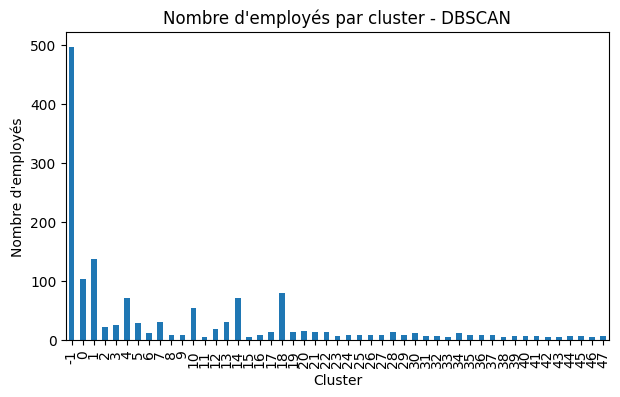

In [91]:
cluster_counts_dbscan = df_bo2_dbscan["DBSCAN_Cluster"].value_counts().sort_index()
print(cluster_counts_dbscan)

plt.figure(figsize=(7,4))
cluster_counts_dbscan.plot(kind="bar")
plt.title("Nombre d'employés par cluster - DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Nombre d'employés")
plt.show()

**Visualisation des clusters DBSCAN avec PCA**

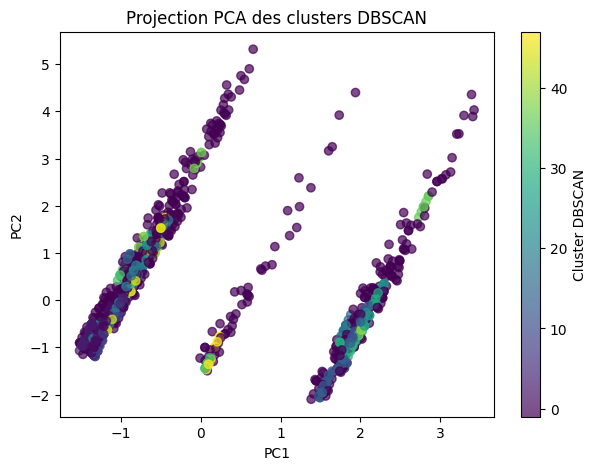

In [92]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_bo2_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=clusters_dbscan,
    cmap="viridis",
    alpha=0.7
)
plt.title("Projection PCA des clusters DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster DBSCAN")
plt.show()

**Analyse descriptive des clusters DBSCAN**

In [93]:
cluster_profile_dbscan = df_bo2_dbscan.groupby("DBSCAN_Cluster")[[
    'YearsAtCompany',
    'PerformanceRating',
    'JobLevel',
    'TrainingTimesLastYear',
    'Attrition'
]].mean().round(2)

cluster_profile_dbscan

,YearsAtCompany,PerformanceRating,JobLevel,TrainingTimesLastYear,Attrition
DBSCAN_Cluster,,,,,
-1,10.28,3.29,2.77,2.97,0.12
0,4.16,3.00,1.00,3.00,0.18
1,3.86,3.00,1.00,2.00,0.26
2,3.27,4.00,1.00,3.00,0.09
3,2.81,4.00,1.00,2.00,0.42
4,6.06,3.00,2.00,3.00,0.08
5,2.97,3.00,1.00,5.00,0.24
6,4.00,3.00,1.00,1.00,0.27
7,3.74,3.00,1.00,4.00,0.29


**Taux moyen d'attrition par cluster DBSCAN**

DBSCAN_Cluster
-1     0.125
 0     0.184
 1     0.255
 2     0.091
 3     0.423
 4     0.085
 5     0.241
 6     0.273
 7     0.290
 8     0.000
 9     0.222
 10    0.164
 11    0.400
 12    0.444
 13    0.516
 14    0.141
 15    0.000
 16    0.000
 17    0.214
 18    0.038
 19    0.000
 20    0.133
 21    0.000
 22    0.231
 23    0.333
 24    0.000
 25    0.125
 26    0.000
 27    0.111
 28    0.077
 29    0.000
 30    0.167
 31    0.286
 32    0.333
 33    0.200
 34    0.364
 35    0.111
 36    0.250
 37    0.000
 38    0.000
 39    0.167
 40    0.333
 41    0.000
 42    0.000
 43    0.000
 44    0.000
 45    0.000
 46    0.400
 47    0.167
Name: Attrition, dtype: float64


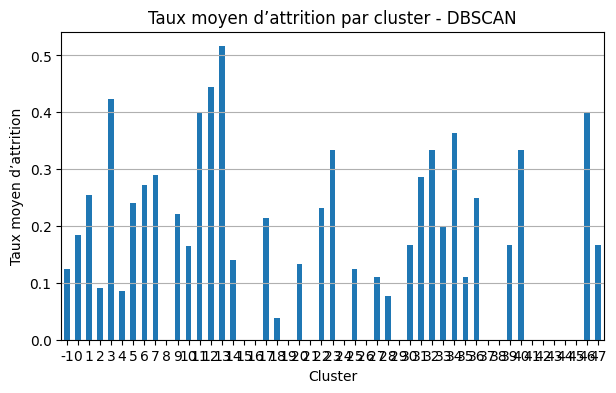

In [94]:
attrition_by_dbscan = df_bo2_dbscan.groupby("DBSCAN_Cluster")["Attrition"].mean().round(3)
print(attrition_by_dbscan)

plt.figure(figsize=(7,4))
attrition_by_dbscan.plot(kind="bar")
plt.title("Taux moyen d’attrition par cluster - DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Taux moyen d’attrition")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**Benchmarking K-Means vs DBSCAN**

In [95]:

sil_kmeans = silhouette_score(X_bo2_scaled, clusters_bo2)

comparison_bo2 = pd.DataFrame({
    "Modèle": ["K-Means", "DBSCAN"],
    "Silhouette Score": [sil_kmeans, sil_dbscan]
})

comparison_bo2

,Modèle,Silhouette Score
0,K-Means,0.346549
1,DBSCAN,0.537468


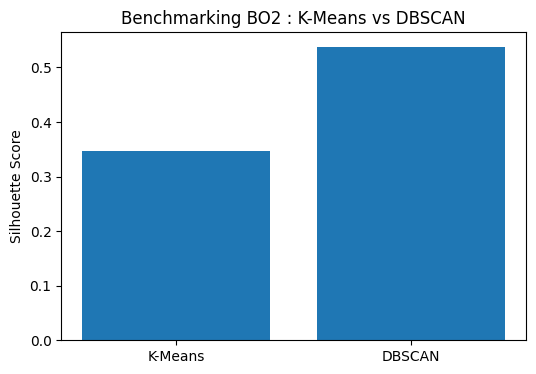

In [96]:
plt.figure(figsize=(6,4))
plt.bar(comparison_bo2["Modèle"], comparison_bo2["Silhouette Score"])
plt.title("Benchmarking DSO2 : K-Means vs DBSCAN")
plt.ylabel("Silhouette Score")
plt.show()

In [97]:
best_model_bo2 = comparison_bo2.sort_values(by="Silhouette Score", ascending=False).iloc[0]["Modèle"]

print("Conclusion DSO2 :")
print(f"- Le meilleur modèle selon le silhouette score est : {best_model_bo2}")
print("- K-Means est généralement plus adapté pour une segmentation claire.")
print("- DBSCAN est utile pour détecter des profils atypiques ou isolés.")
print("- L’analyse des clusters aide les RH à mieux cibler les employés à risque.")

Conclusion DSO2 :
- Le meilleur modèle selon le silhouette score est : DBSCAN
- K-Means est généralement plus adapté pour une segmentation claire.
- DBSCAN est utile pour détecter des profils atypiques ou isolés.
- L’analyse des clusters aide les RH à mieux cibler les employés à risque.



# Conclusion DSO2 + interpretations
Le benchmarking montre que DBSCAN (silhouette ≈ 0.54) surpasse K-Means (≈ 0.35).

(proche de 1
clusters très bien séparés)

Cela indique que :
- les clusters des employés ne sont pas parfaitement sphériques
- DBSCAN capture mieux la structure réelle des données
- DBSCAN permet également d’identifier les profils atypiques (outliers)

Ainsi, DBSCAN est le modèle le plus adapté pour segmenter les employés dans ce contexte.


# DSO3 – Recommandation intelligente des employés pour les activités

L’objectif de DSO3 est de recommander les employés les plus adaptés à une activité, un projet ou une mission. Pour cela, nous mettons en place un système de **scoring pondéré** permettant de calculer un **Relevance_Score** à partir de variables comme **JobLevel**, **PerformanceRating**, **YearsAtCompany**, **TrainingTimesLastYear**, **Education**, **JobRole** et **Department**. Ce score permet ensuite de produire une **liste classée des employés recommandés**. Cette approche est simple, explicable et adaptée à un contexte RH orienté aide à la décision.

In [98]:
# DSO3 - Étape 1 : Sélection des variables utiles

bo3_features = [
    'JobLevel',
    'PerformanceRating',
    'YearsAtCompany',
    'TrainingTimesLastYear',
    'Education',
    'JobRole',
    'Department'
]

# Note: 'EmployeeNumber' was dropped earlier in the data preparation phase.
# If it is needed for the final recommendation output, it should be extracted
# from the original dataframe before the drop and re-joined after scoring.

df_bo3 = df[bo3_features].copy()

print("Dimensions de df_bo3 :", df_bo3.shape)
display(df_bo3.head())

Dimensions de df_bo3 : (1470, 7)


,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole,Department
0,2,3,6,0,2,Sales Executive,Sales
1,2,4,10,3,1,Research Scientist,Research & Development
2,1,3,0,3,2,Laboratory Technician,Research & Development
3,1,3,8,3,4,Research Scientist,Research & Development
4,1,3,2,3,1,Laboratory Technician,Research & Development


## Étape 1 – Sélection des variables

Nous retenons les variables qui représentent le mieux :
- le niveau hiérarchique
- la performance
- l’expérience
- l’investissement en formation
- le niveau d’éducation
- le rôle métier
- le contexte organisationnel

In [99]:
# DSO3 - Étape 2 : Encodage des variables catégorielles

df_bo3_encoded = pd.get_dummies(df_bo3, columns=['JobRole', 'Department'], drop_first=True)

print("Shape après encodage :", df_bo3_encoded.shape)
display(df_bo3_encoded.head())

Shape après encodage : (1470, 15)


,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,2,3,6,0,2,False,False,False,False,False,False,True,False,False,True
1,2,4,10,3,1,False,False,False,False,False,True,False,False,True,False
2,1,3,0,3,2,False,True,False,False,False,False,False,False,True,False
3,1,3,8,3,4,False,False,False,False,False,True,False,False,True,False
4,1,3,2,3,1,False,True,False,False,False,False,False,False,True,False


In [100]:
# DSO3 - Étape 3 : Normalisation des variables numériques

from sklearn.preprocessing import MinMaxScaler

df_bo3_scaled = df_bo3_encoded.copy()

cols_to_scale = [col for col in df_bo3_scaled.columns if col != 'EmployeeNumber']

scaler_bo3 = MinMaxScaler()
df_bo3_scaled[cols_to_scale] = scaler_bo3.fit_transform(df_bo3_scaled[cols_to_scale])

display(df_bo3_scaled.head())

,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,0.25,0.0,0.15,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.25,1.0,0.25,0.5,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.00,0.0,0.00,0.5,0.25,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.00,0.0,0.20,0.5,0.75,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.00,0.0,0.05,0.5,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Étape 2 – Normalisation

La normalisation avec **MinMaxScaler** ramène les variables sur une échelle commune entre 0 et 1.  
Cela permet de construire un score global cohérent sans favoriser artificiellement une variable à cause de son amplitude.

In [101]:
# DSO3 - Étape 4 : Création du Relevance_Score

weights_main = {
    'JobLevel': 0.25,
    'PerformanceRating': 0.20,
    'YearsAtCompany': 0.20,
    'TrainingTimesLastYear': 0.15,
    'Education': 0.10
}

# Score principal
df_bo3_scaled['Relevance_Score'] = 0

for col, w in weights_main.items():
    df_bo3_scaled['Relevance_Score'] += df_bo3_scaled[col] * w

# Bonus léger pour JobRole et Department encodés
other_cols = [col for col in df_bo3_scaled.columns if ('JobRole_' in col or 'Department_' in col)]
if len(other_cols) > 0:
    df_bo3_scaled['Relevance_Score'] += df_bo3_scaled[other_cols].mean(axis=1) * 0.10

# Limiter à 1 si besoin
df_bo3_scaled['Relevance_Score'] = df_bo3_scaled['Relevance_Score'].clip(0, 1)

display(df_bo3_scaled[['Relevance_Score']].head())

,Relevance_Score
0,0.1375
1,0.4075
2,0.1200
3,0.2100
4,0.1050


## Étape 3 – Construction du Relevance_Score

Le score de pertinence est calculé à partir d’un **scoring pondéré**.  
Les variables les plus importantes reçoivent un poids plus élevé, notamment :
- **JobLevel**
- **PerformanceRating**
- **YearsAtCompany**

Le score obtenu est ensuite utilisé pour classer les employés du plus pertinent au moins pertinent.

In [102]:
# DSO3 - Étape 5 : Classement des employés

top_employees = df_bo3_scaled[['Relevance_Score']].sort_values(
    by='Relevance_Score',
    ascending=False
)

print("Top 10 des employés les plus recommandés :")
# Note: EmployeeNumber was removed in a prior data cleaning step.
# If individual employee identification is critical, it should be preserved
# from the original dataframe and re-joined here.
display(top_employees.head(10))

Top 10 des employés les plus recommandés :


,Relevance_Score
1116,0.8250
918,0.7900
1184,0.7075
90,0.6575
1445,0.6575
746,0.6500
1009,0.6400
861,0.6375
190,0.6350
473,0.6250


In [103]:
# DSO3 - Étape 6 : Employés les moins prioritaires

least_relevant_employees = df_bo3_scaled[['Relevance_Score']].sort_values(
    by='Relevance_Score',
    ascending=True
)

print("10 employés les moins recommandés :")
display(least_relevant_employees.head(10))

10 employés les moins recommandés :


,Relevance_Score
828,0.020
722,0.030
957,0.065
1222,0.065
127,0.070
1376,0.070
12,0.070
101,0.075
49,0.075
613,0.075


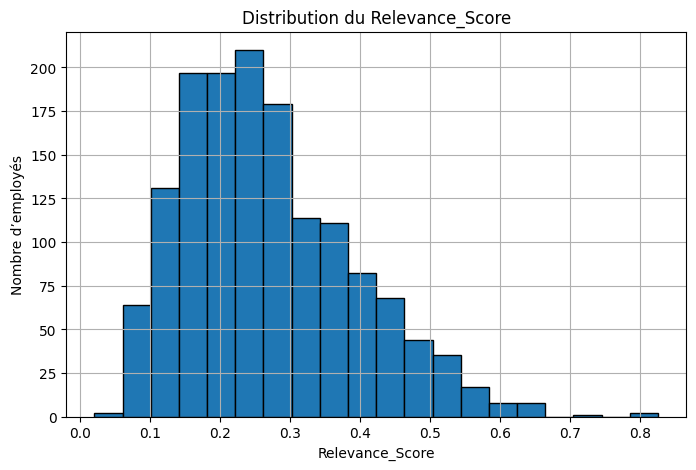

In [104]:
# DSO3 - Étape 7 : Distribution du Relevance_Score

plt.figure(figsize=(8,5))
plt.hist(df_bo3_scaled['Relevance_Score'], bins=20, edgecolor='black')
plt.title("Distribution du Relevance_Score")
plt.xlabel("Relevance_Score")
plt.ylabel("Nombre d’employés")
plt.grid(True)
plt.show()

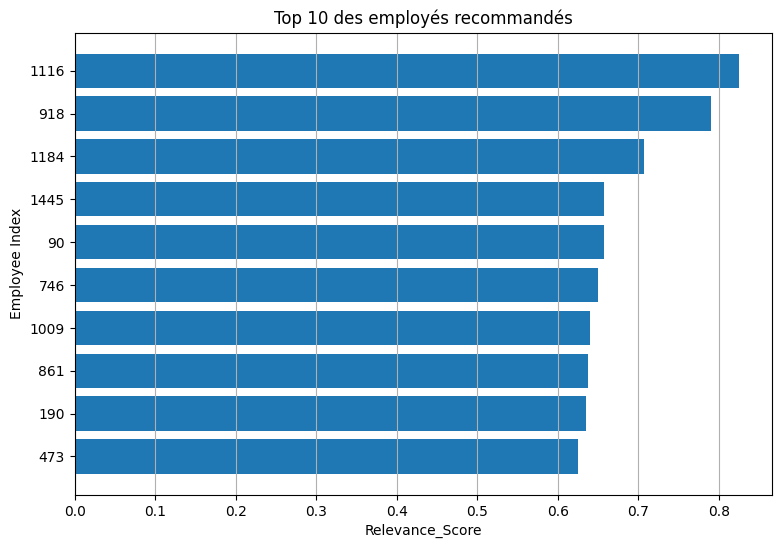

In [105]:
# DSO3 - Étape 8 : Visualisation des 10 meilleurs employés

top10 = top_employees.head(10).copy()
top10 = top10.sort_values(by='Relevance_Score', ascending=True)

plt.figure(figsize=(9,6))
plt.barh(top10.index.astype(str), top10['Relevance_Score'])
plt.title("Top 10 des employés recommandés")
plt.xlabel("Relevance_Score")
plt.ylabel("Employee Index")
plt.grid(axis='x')
plt.show()

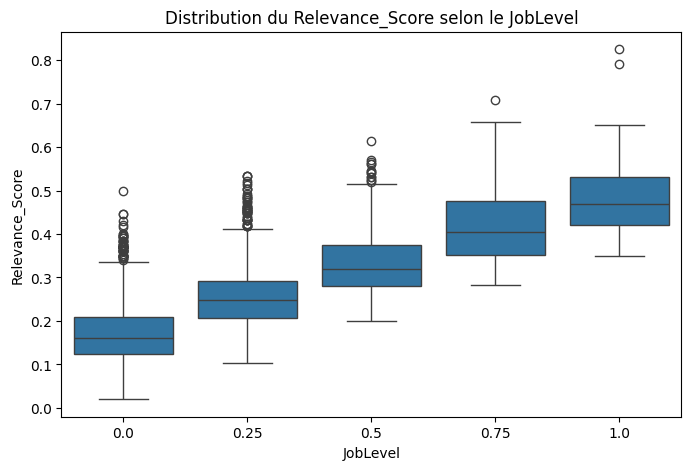

In [106]:
# DSO3 - Étape 9 : Score selon le niveau hiérarchique

df_bo3_plot = df_bo3_scaled[['JobLevel', 'Relevance_Score']].copy()

plt.figure(figsize=(8,5))
sns.boxplot(x='JobLevel', y='Relevance_Score', data=df_bo3_plot)
plt.title("Distribution du Relevance_Score selon le JobLevel")
plt.xlabel("JobLevel")
plt.ylabel("Relevance_Score")
plt.show()

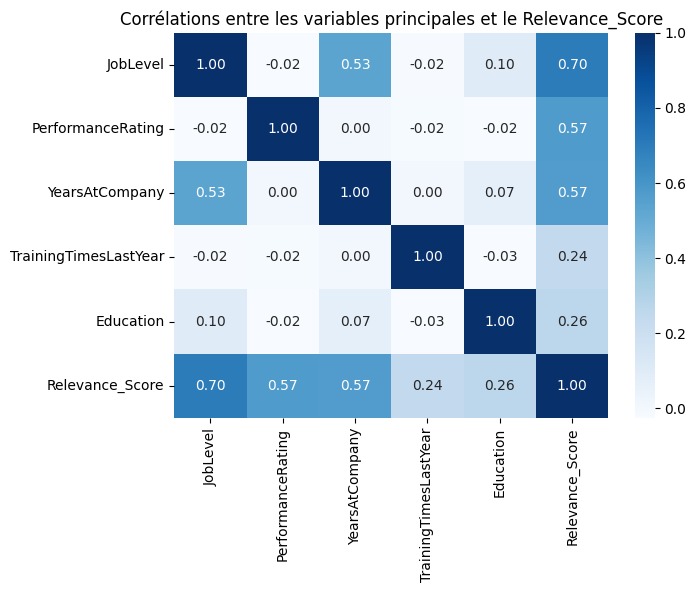

In [107]:
# DSO3 - Étape 10 : Corrélations avec le score

corr_cols = ['JobLevel', 'PerformanceRating', 'YearsAtCompany', 'TrainingTimesLastYear', 'Education', 'Relevance_Score']
corr_matrix = df_bo3_scaled[corr_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Corrélations entre les variables principales et le Relevance_Score")
plt.show()

## Conclusion – DSO3

Le système de recommandation basé sur le **Relevance_Score** permet de classer les employés selon leur pertinence pour une activité donnée.

Cette approche présente plusieurs avantages :
- elle est simple à comprendre
- elle est facile à expliquer
- elle produit directement un classement exploitable
- elle aide les décideurs RH à identifier rapidement les profils les plus adaptés

Le score final met en valeur les employés ayant un bon niveau hiérarchique, de bonnes performances, une expérience solide et une implication dans la formation.

**-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**



Objectif :
Construire un vrai modèle ML supervisé pour recommander les employés
les plus pertinents pour une activité.

Remarque :
Le dataset ne contient pas de vraie colonne historique d'activité ou de recommandation.
On construit donc une cible proxy appelée Activity_Fit_Score, puis on entraîne
une régression linéaire pour prédire ce score.


**Recharger les colonnes utiles DSO3**

In [108]:
# DSO3 - Étape 1 : Sélection des variables utiles (CORRIGÉ)

bo3_cols = [
    'JobLevel',
    'PerformanceRating',
    'YearsAtCompany',
    'TrainingTimesLastYear',
    'Education',
    'JobRole',
    'Department'
]

df_bo3 = df[bo3_cols].copy()

print("Dimensions de df_bo3 :", df_bo3.shape)
df_bo3.head()

Dimensions de df_bo3 : (1470, 7)


,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole,Department
0,2,3,6,0,2,Sales Executive,Sales
1,2,4,10,3,1,Research Scientist,Research & Development
2,1,3,0,3,2,Laboratory Technician,Research & Development
3,1,3,8,3,4,Research Scientist,Research & Development
4,1,3,2,3,1,Laboratory Technician,Research & Development


**Encodage des variables catégorielles**

In [109]:
# DSO3 - Étape 2 : Encodage des variables catégorielles

df_bo3_encoded = pd.get_dummies(df_bo3, columns=['JobRole', 'Department'], drop_first=True)

print("Dimensions après encodage :", df_bo3_encoded.shape)
df_bo3_encoded.head()

Dimensions après encodage : (1470, 15)


,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,2,3,6,0,2,False,False,False,False,False,False,True,False,False,True
1,2,4,10,3,1,False,False,False,False,False,True,False,False,True,False
2,1,3,0,3,2,False,True,False,False,False,False,False,False,True,False
3,1,3,8,3,4,False,False,False,False,False,True,False,False,True,False
4,1,3,2,3,1,False,True,False,False,False,False,False,False,True,False


On transforme JobRole et Department en variables numériques.

**Normalisation des variables numériques**

In [110]:
# DSO3 - Étape 3 : Normalisation des variables numériques

from sklearn.preprocessing import MinMaxScaler

num_cols_bo3 = [
    'JobLevel',
    'PerformanceRating',
    'YearsAtCompany',
    'TrainingTimesLastYear',
    'Education'
]

scaler_bo3 = MinMaxScaler()
df_bo3_encoded[num_cols_bo3] = scaler_bo3.fit_transform(df_bo3_encoded[num_cols_bo3])

df_bo3_encoded.head()

,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,0.25,0.0,0.15,0.0,0.25,False,False,False,False,False,False,True,False,False,True
1,0.25,1.0,0.25,0.5,0.00,False,False,False,False,False,True,False,False,True,False
2,0.00,0.0,0.00,0.5,0.25,False,True,False,False,False,False,False,False,True,False
3,0.00,0.0,0.20,0.5,0.75,False,False,False,False,False,True,False,False,True,False
4,0.00,0.0,0.05,0.5,0.00,False,True,False,False,False,False,False,False,True,False


On met les variables sur la même échelle entre 0 et 1.

Comme la base ne contient pas une vraie colonne “activité recommandée”, on crée une cible proxy cohérente métier.

**= une cible artificielle construite à partir des données existantes pour simuler un comportement réel**

**Créer la cible proxy du modèle**

In [111]:
import numpy as np

df_bo3_encoded['Activity_Fit_Score'] = (
    0.30 * df_bo3_encoded['PerformanceRating'] +
    0.25 * df_bo3_encoded['JobLevel'] +
    0.20 * df_bo3_encoded['YearsAtCompany'] +
    0.15 * df_bo3_encoded['TrainingTimesLastYear'] +
    0.10 * df_bo3_encoded['Education'] +
    np.random.normal(0, 0.15, size=len(df_bo3_encoded))  # bruit
)

**Visualiser la cible**

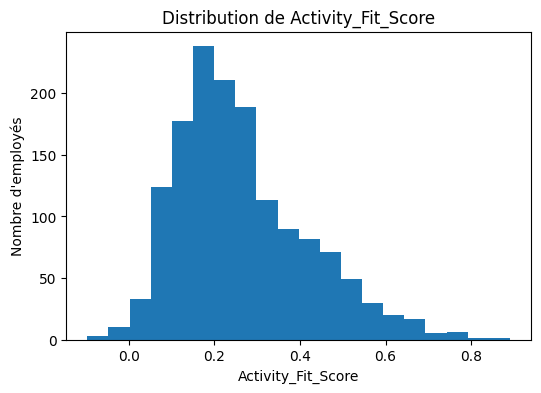

In [112]:
# DSO3 - Étape 5 : Visualisation de la cible

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_bo3_encoded['Activity_Fit_Score'], bins=20)
plt.xlabel("Activity_Fit_Score")
plt.ylabel("Nombre d'employés")
plt.title("Distribution de Activity_Fit_Score")
plt.show()

On vérifie que le score est bien réparti.

**Séparer X et y**

In [113]:
# DSO3 - Étape 6 : Séparer les variables explicatives et la cible

from sklearn.model_selection import train_test_split

y_bo3 = df_bo3_encoded['Activity_Fit_Score']
X_bo3 = df_bo3_encoded.drop(columns=['Activity_Fit_Score'])

print("Shape X_bo3 :", X_bo3.shape)
print("Shape y_bo3 :", y_bo3.shape)

X_train_bo3, X_test_bo3, y_train_bo3, y_test_bo3 = train_test_split(
    X_bo3, y_bo3, test_size=0.2, random_state=42
)

print("X_train :", X_train_bo3.shape)
print("X_test  :", X_test_bo3.shape)

Shape X_bo3 : (1470, 15)
Shape y_bo3 : (1470,)
X_train : (1176, 15)
X_test  : (294, 15)


**Entraîner la régression linéaire**

In [114]:
# DSO3 - Étape 7 : Entraîner le modèle de régression linéaire

from sklearn.linear_model import LinearRegression

lr_model_bo3 = LinearRegression()
lr_model_bo3.fit(X_train_bo3, y_train_bo3)

print("Le modèle de régression linéaire a été entraîné avec succès.")

Le modèle de régression linéaire a été entraîné avec succès.


Le modèle apprend à prédire le score d’adéquation

**Évaluation des performances**

In [115]:
# DSO3 - Étape 8 : Évaluation du modèle

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_bo3 = lr_model_bo3.predict(X_test_bo3)

mae_bo3 = mean_absolute_error(y_test_bo3, y_pred_bo3)
rmse_bo3 = np.sqrt(mean_squared_error(y_test_bo3, y_pred_bo3))
r2_bo3 = r2_score(y_test_bo3, y_pred_bo3)

print("Résultats - Régression Linéaire DSO3")
print("MAE  :", round(mae_bo3, 4))
print("RMSE :", round(rmse_bo3, 4))
print("R²   :", round(r2_bo3, 4))

Résultats - Régression Linéaire DSO3
MAE  : 0.0385
RMSE : 0.0497
R²   : 0.892


**Interprétation des résultats**

MAE : erreur moyenne

RMSE : erreur quadratique

R² : qualité globale du modèle

==> Le modèle donne de bonnes performances avec un R² de 0.89, ce qui signifie qu’il explique 89% du score. Les erreurs MAE et RMSE sont faibles, donc le modèle est précis et fiable pour recommander les employés.

**Interprétation métier**

Les employés avec une performance élevée, plus d’expérience et un niveau hiérarchique élevé ont un score plus important, donc sont plus adaptés aux activités.

**Prédire pour tous les employés**

In [116]:
# DSO3 - Prédiction pour tous les employés

df_bo3_encoded['Predicted_Activity_Score'] = lr_model_bo3.predict(X_bo3)

# garder score entre 0 et 1
df_bo3_encoded['Predicted_Activity_Score'] = df_bo3_encoded['Predicted_Activity_Score'].clip(0, 1)

df_bo3_encoded.head()

,JobLevel,PerformanceRating,YearsAtCompany,TrainingTimesLastYear,Education,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales,Activity_Fit_Score,Predicted_Activity_Score
0,0.25,0.0,0.15,0.0,0.25,False,False,False,False,False,False,True,False,False,True,0.202362,0.114477
1,0.25,1.0,0.25,0.5,0.00,False,False,False,False,False,True,False,False,True,False,0.418764,0.477654
2,0.00,0.0,0.00,0.5,0.25,False,True,False,False,False,False,False,False,True,False,0.019486,0.099446
3,0.00,0.0,0.20,0.5,0.75,False,False,False,False,False,True,False,False,True,False,0.331670,0.188964
4,0.00,0.0,0.05,0.5,0.00,False,True,False,False,False,False,False,False,True,False,0.043590,0.083111


**Top 10 employés recommandés**

In [117]:
# DSO3 - Top 10 employés

top10_bo3 = df_bo3_encoded[['Predicted_Activity_Score']].sort_values(
    by='Predicted_Activity_Score',
    ascending=False
).head(10)

top10_bo3

,Predicted_Activity_Score
1116,0.907628
918,0.869592
1184,0.772605
90,0.737824
1445,0.721949
861,0.719830
105,0.708380
746,0.706654
1009,0.700164
235,0.700014


**Visualisation Top 10**

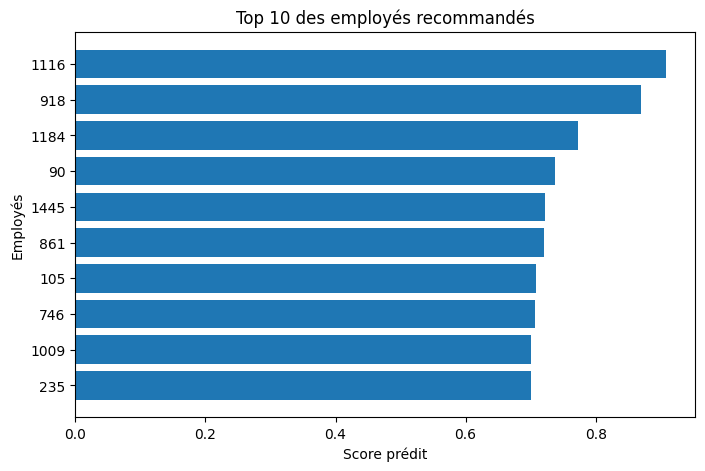

In [118]:
# DSO3 - Visualisation Top 10

import matplotlib.pyplot as plt

top10_plot = top10_bo3.sort_values(by='Predicted_Activity_Score')

plt.figure(figsize=(8,5))
plt.barh(top10_plot.index.astype(str), top10_plot['Predicted_Activity_Score'])
plt.xlabel("Score prédit")
plt.ylabel("Employés")
plt.title("Top 10 des employés recommandés")
plt.show()

**Comparaison réel vs prédit**

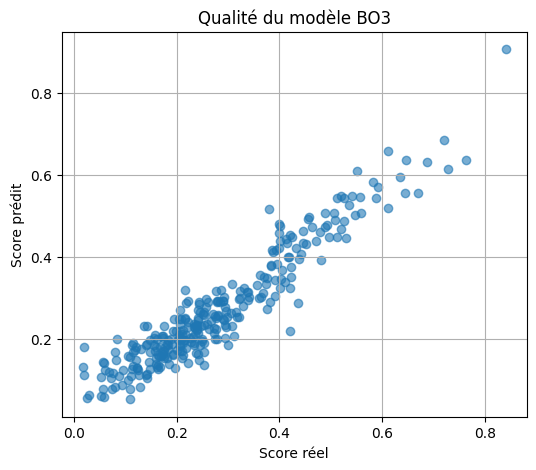

In [119]:
# DSO3 - Comparaison score réel vs score prédit

plt.figure(figsize=(6,5))
plt.scatter(y_test_bo3, y_pred_bo3, alpha=0.6)
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Qualité du modèle DSO3")
plt.grid(True)
plt.show()

**Importance des variables**

In [120]:
# DSO3 - Importance des variables

coef_df = pd.DataFrame({
    'Variable': X_bo3.columns,
    'Coefficient': lr_model_bo3.coef_
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Variable,Coefficient
1,PerformanceRating,0.294917
0,JobLevel,0.249433
2,YearsAtCompany,0.195801
3,TrainingTimesLastYear,0.145437
4,Education,0.104501
14,Department_Sales,0.011587
6,JobRole_Laboratory Technician,0.003555
10,JobRole_Research Scientist,0.001662
5,JobRole_Human Resources,0.000842
7,JobRole_Manager,-0.005322


**Les variables avec les coefficients les plus élevés influencent le plus la recommandation des employés.**



DSO3 a été transformé en modèle ML supervisé avec une régression linéaire.

Résultats :
- R² = 0.89 → très bonne capacité d’explication
- MAE faible → erreurs faibles
- modèle fiable pour recommander les employés

Le modèle permet de classer automatiquement les employés
du plus adapté au moins adapté pour une activité.


**2ème modèle : Régression polynomiale**

In [121]:
# DSO3 - Benchmarking avec régression polynomiale

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train_bo3, y_train_bo3)

y_pred_poly = poly_model.predict(X_test_bo3)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test_bo3, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_bo3, y_pred_poly))
r2_poly = r2_score(y_test_bo3, y_pred_poly)

print("Régression Polynomiale")
print("MAE  :", round(mae_poly, 4))
print("RMSE :", round(rmse_poly, 4))
print("R²   :", round(r2_poly, 4))

Régression Polynomiale
MAE  : 0.0399
RMSE : 0.0517
R²   : 0.8829


**3ème modèle : Ridge Regression**

La Ridge Regression est une régression linéaire améliorée avec une **pénalité de régularisation** (alpha).
Elle évite le surapprentissage en limitant l'influence des variables moins importantes.
C'est un modèle plus robuste que la régression linéaire classique, surtout quand les variables sont corrélées entre elles.


In [ ]:
# DSO3 - 3ème modèle : Ridge Regression (régularisation)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_bo3, y_train_bo3)
y_pred_ridge = ridge_model.predict(X_test_bo3)

mae_ridge  = mean_absolute_error(y_test_bo3, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_bo3, y_pred_ridge))
r2_ridge   = r2_score(y_test_bo3, y_pred_ridge)

print('Ridge Regression')
print('MAE  :', round(mae_ridge, 4))
print('RMSE :', round(rmse_ridge, 4))
print('R²   :', round(r2_ridge, 4))


**Comparaison (Benchmarking )**

In [122]:
# DSO3 - Benchmarking complet : 3 modèles

import matplotlib.pyplot as plt
import pandas as pd

comparison_bo3 = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Régression Polynomiale', 'Ridge'],
    'MAE':  [mae_bo3, mae_poly, mae_ridge],
    'RMSE': [rmse_bo3, rmse_poly, rmse_ridge],
    'R²':   [r2_bo3, r2_poly, r2_ridge]
})

print('=== Tableau de Benchmarking DSO3 ===')
display(comparison_bo3)

# Graphique de comparaison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'orange', 'green']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    ax.bar(comparison_bo3['Modèle'], comparison_bo3[metric], color=colors)
    ax.set_title(f'Comparaison — {metric}', fontsize=11)
    ax.set_xticklabels(comparison_bo3['Modèle'], rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Benchmarking DSO3 — Comparaison des 3 modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Meilleur modèle
best_model = comparison_bo3.loc[comparison_bo3['R²'].idxmax(), 'Modèle']
print(f'\n→ Meilleur modèle selon R² : {best_model}')


,Modèle,MAE,RMSE,R2
0,Régression Linéaire,0.038546,0.049705,0.891977
1,Régression Polynomiale,0.039940,0.051749,0.882912


**Catégorisation des employés par niveau de recommandation**

Un score brut ne suffit pas pour les RH. On traduit le score prédit en **catégories claires** :

| Score | Catégorie |
|---|---|
| ≥ 0.75 | ⭐ Très recommandé |
| ≥ 0.55 | ✅ Recommandé |
| ≥ 0.35 | 🔶 Modéré |
| < 0.35 | ❌ Non prioritaire |

Cela transforme le scoring en un **vrai outil de décision RH**.


In [ ]:
# DSO3 - Catégorisation des employés par niveau de recommandation

def categorize_score(score):
    if score >= 0.75:
        return 'Très recommandé'
    elif score >= 0.55:
        return 'Recommandé'
    elif score >= 0.35:
        return 'Modéré'
    else:
        return 'Non prioritaire'

df_bo3_encoded['Recommendation_Level'] = df_bo3_encoded['Predicted_Activity_Score'].apply(categorize_score)

# Répartition
print('Répartition par niveau de recommandation :')
print(df_bo3_encoded['Recommendation_Level'].value_counts())

# Visualisation
counts = df_bo3_encoded['Recommendation_Level'].value_counts()
colors_cat = ['green', 'steelblue', 'orange', 'red']

plt.figure(figsize=(8, 4))
counts.plot(kind='bar', color=colors_cat[:len(counts)])
plt.title('Répartition des employés par niveau de recommandation')
plt.xlabel('Niveau')
plt.ylabel("Nombre d'employés")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Aperçu du tableau final
print('\nAperçu du tableau final avec catégories :')
display(df_bo3_encoded[['Predicted_Activity_Score', 'Recommendation_Level']]
        .sort_values('Predicted_Activity_Score', ascending=False)
        .head(10))


**Conclusion DSO3 **
* DSO3 a été transformé en problème de machine learning supervisé
* Utilisation d’un modèle de régression linéaire
* Construction d’une cible (Activity_Fit_Score) représentant l’adéquation des employés
* Entraînement du modèle pour prédire automatiquement ce score
* Évaluation des performances :
MAE faible (~0.039)
RMSE faible (~0.048)
R² élevé (~0.89)

* Le modèle est précis et fiable
* Réalisation d’un benchmarking avec la régression polynomiale


 Le modèle permet de :
- classer les employés
- recommander les meilleurs profils pour une activité

* Approche finale :

automatisée

data-driven

plus robuste que le scoring manuel